## Helpers

In [103]:
import torch
import math
import seaborn as sns

# set seed
torch.manual_seed(42)
sns.set_theme()
sns.set_palette("colorblind")

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D,D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    if a1.ndim == 1:
        a1 = a1.unsqueeze(0)
    if a2.ndim == 1:
        a2 = a2.unsqueeze(0)
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    return torch.linalg.norm(diff, dim=0).mean().item()

# For debugging
def interference_abs(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    assert a1.ndim == 1 and a2.ndim == 1, "a1 and a2 must be 1D"
    diffs = (a1 - a2) @ x.T  # shape (N,)
    return diffs.abs().mean().item()

def rot2d(theta: float) -> torch.Tensor:
    # Only supports 2D rotation
    tt = torch.tensor(theta)
    return torch.tensor([
        [torch.cos(tt), -torch.sin(tt)],
        [torch.sin(tt),  torch.cos(tt)]
    ])

def create_datasets_and_task_vectors_2d(theta, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000, t0idx=-1, sigma_mag=0.0):
    # thetas is a list of angles
    t0 = torch.eye(2)[t0idx]
    t1 = rot2d(theta) @ t0
    task_vectors = torch.stack([t0, t1], dim=0) # (N, D) = (2, 2)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)

    if sigma_mag > 0.0:
        task_vectors = task_vectors * (1.0 + (torch.randn(2, 1) * sigma_mag))

    n_tasks, d_task = task_vectors.shape[0], task_vectors.shape[1]
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors


def create_datasets_and_task_vectors(n_tasks=3, d_task=32, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000):
    task_vectors = torch.randn(n_tasks, d_task)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    # random scaling but same direction
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv_mags(x: torch.Tensor, mags=False):
    """Merges task vectors x: (N, D)"""
    # make all xs unit vectors
    N, D = x.shape
    m = torch.linalg.norm(x, dim=1, keepdim=True) if mags else torch.ones(N)
    print(m)
    x_unit = x / m
    # u, _, vt = torch.linalg.svd(x_unit, full_matrices=False)
    q = compute_procrustes(x_unit.T).T  
    # add mags
    return (m * q).sum(dim=0)



def cos_sim(a, b):
    a, b = a.flatten(), b.flatten()
    return a.T @ b / (torch.linalg.norm(a) * torch.linalg.norm(b))


def merge_dwa1(us):
    """Merges task vectors using the DWA method.
    
    Args:
        us (torch.Tensor): (N, D)

    Returns:
        torch.Tensor: (N, *)
    """
    N, D = us.shape
    us_expanded = us.unsqueeze(0).repeat(N, 1, 1)
    m = torch.arange(1, N+1)  # multipliers
    w = m.reshape(-1, 1, 1) * us_expanded
    w = w / N**2
    w = w.sum(dim=0)
    return w.sum(dim=0)

def merge_dwa2(us, mode='all', p=0.5):
    N, D = us.shape
    P = math.pow(N, p)
    C = 2*P/(N*N*(N+1))
    us_expanded = us.unsqueeze(0).repeat(N, 1, 1)
    alphas = torch.arange(1, N+1) * C

    if mode != 'all':
        # boundary sum only
        # multiply by 0 for all but the first and last alpha
        alphas = (torch.eye(N)[0] + torch.eye(N)[-1]) * alphas

    w = us_expanded * alphas.reshape(-1, 1, 1)
    w = w.sum(dim=0).sum(dim=0)  # (D,)
    return w


# Test merge_dwa
u1, u2 = 2*torch.eye(2)[0], torch.eye(2)[0]
tvs = torch.stack([u1, u2], dim=0)
us = torch.stack([u1, u2], dim=0)
w = merge_tsv_mags(us)
w


tensor([1., 1.])


tensor([1.3416, 0.4472])

## Synthetic Data

### TSV Multi-Task Interference

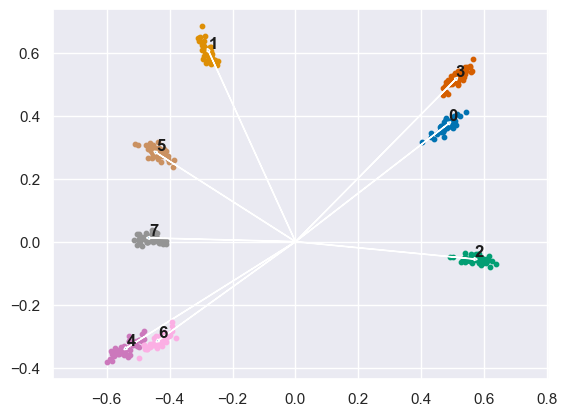

In [24]:
import torch
import matplotlib.pyplot as plt

# set seed
torch.manual_seed(42)

x, tvs = create_datasets_and_task_vectors(n_tasks=8, d_task=8, sigma_perturb=0.01, sigma_scale=0.05, n_samples=50)
for i in range(tvs.shape[0]):
    plt.scatter(x[:,i,0], x[:,i,1], s=10)
    plt.arrow(0, 0, tvs[i,0], tvs[i,1], head_width=0.01, head_length=0.01)
    plt.text(tvs[i,0], tvs[i,1], f"{i}", fontsize=12, color='k', ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_34720/1738435916.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)


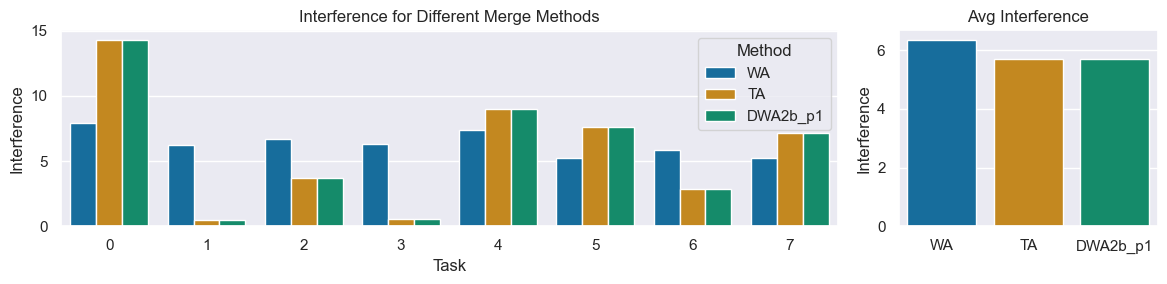

In [25]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I)."""
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    norm = torch.linalg.norm(diff, dim=0)  # shape (N,)
    return norm.mean().item()

w_ta = tvs.sum(dim=0)     # (D,)
w_wa = tvs.mean(dim=0)    # (D,)
w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
w_dwa1 = merge_dwa1(tvs)
w_dwa2a = merge_dwa2(tvs, mode='all')
w_dwa2b = merge_dwa2(tvs, mode='boundary')
w_dwab_p1 = merge_dwa2(tvs, p=1)
n_tasks = tvs.shape[0]

data = []
for t in range(n_tasks):
    data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_ds(w_tsv, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'TA', 'Interference': interference_ds(w_ta, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'WA', 'Interference': interference_ds(w_wa, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_ds(w_dwa1, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'DWA2a', 'Interference': interference_ds(w_dwa2a, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'DWA2b', 'Interference': interference_ds(w_dwa2b, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'DWA2b_p1', 'Interference': interference_ds(w_dwab_p1, tvs[t], x[:,t])})
df = pd.DataFrame(data)

# Compute average interference for each method
avg_interference = df.groupby('Method')['Interference'].mean().reset_index()

# Specify a consistent palette for both plots, matching the order of methods
method_order = ['WA', 'TA', 'DWA2b_p1']
palette = dict(zip(method_order, sns.color_palette("colorblind", n_colors=len(method_order))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3), width_ratios=[3,1])

sns.barplot(data=df, x='Task', y='Interference', hue='Method', ax=ax1, palette=palette, hue_order=method_order)
ax1.set(title="Interference for Different Merge Methods", xlabel='Task', ylabel='Interference')

sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)
ax2.set(title="Avg Interference", ylabel='Interference', xlabel='')

plt.tight_layout()
plt.show()

<Axes: >

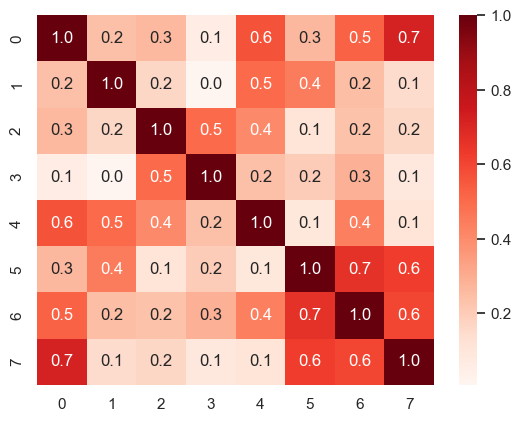

In [4]:
# Compute the proper cosine similarity matrix between all pairs of task vectors
tvs_norm = tvs / tvs.norm(dim=1, keepdim=True)  # (n_tasks, D)
cosim = tvs_norm @ tvs_norm.T  # (n_tasks, n_tasks)
cosim = cosim.abs()

# Use a perceptually uniform palette for the heatmap (cmap="viridis" or "mako")
sns.heatmap(
    cosim.cpu().numpy(), 
    fmt=".1f", 
    cbar=True, 
    cmap="Reds",    # Try 'mako', 'viridis', or 'rocket' for a better palette
    annot=True      # Optional: show values
)

### TSV 2-Task Partial Interference Sweep -- Unit Vector

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_26513/1496166391.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


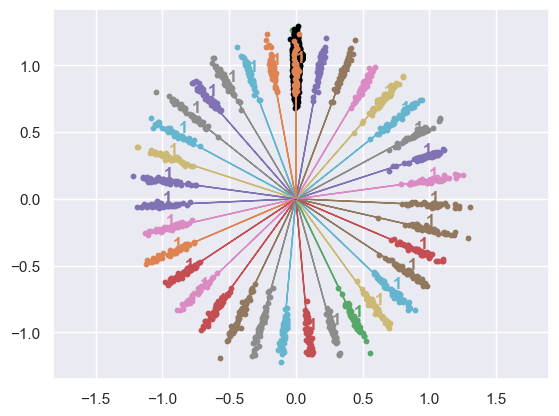

In [5]:
import torch
import math
import matplotlib.pyplot as plt
import random
sns.set_theme()

exps = []
for idx, theta_v in enumerate(torch.linspace(0, math.pi*2, steps=36)):
    x, tvs = create_datasets_and_task_vectors_2d(theta_v, sigma_perturb=0.01, sigma_scale=0.1, n_samples=50)
    exps.append((x, tvs, theta_v))
    for t in range(2):
        color = 'black' if t == 0 else random.choice(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'])
        plt.scatter(x[:,t,0], x[:,t,1], s=10, color=color, label=f'Task {t}' if idx == 0 else None)
        plt.arrow(0, 0, tvs[t,0], tvs[t,1], head_width=0.01, head_length=0.01, color=color)
        plt.text(tvs[t,0], tvs[t,1], f"{t}", fontsize=12, color=color, ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


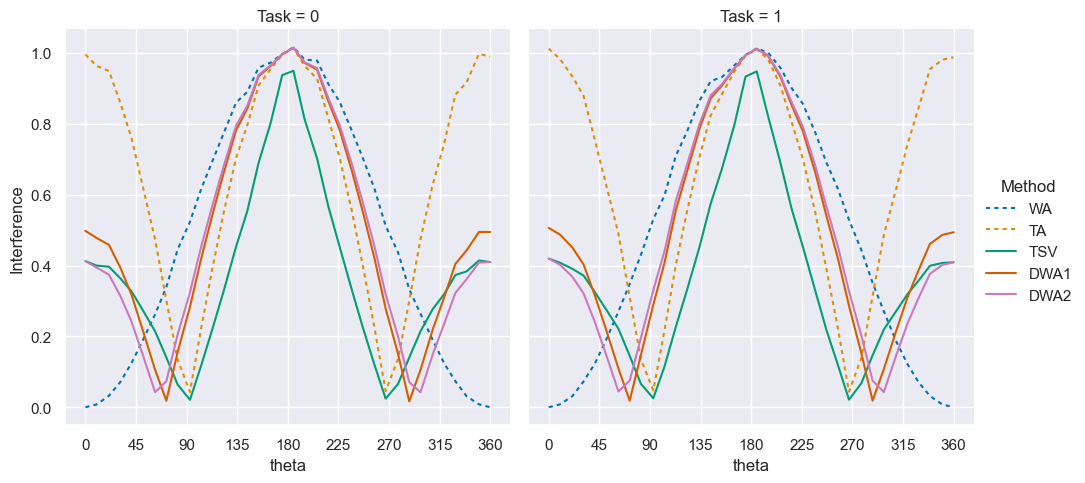

In [6]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd
sns.set_theme()
sns.set_palette("colorblind")

data = []
for x, tvs, theta_v in exps:
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    w_dwa1 = merge_dwa1(tvs)
    w_dwa2 = merge_dwa2(tvs)
    n_tasks = tvs.shape[0]
    theta_deg = torch.round(theta_v * 180 / math.pi).item()
    for t in range(n_tasks):
        data.append({'Task': t, 'Method': 'WA', 'Interference': interference_abs(w_wa, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TA', 'Interference': interference_abs(w_ta, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_abs(w_tsv, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_abs(w_dwa1, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'DWA2', 'Interference': interference_abs(w_dwa2, tvs[t], x[:,t]), 'theta': theta_deg})
df = pd.DataFrame(data)

# Emphasize TSV in palette and marker
# g = sns.relplot(data=df, x='theta', y='Interference', kind='line', col='Task', style='Method',  hue='Method', dashes={"TSV": "", "DWA": "", "TA": (2, 2), "WA": (2, 2)})
g = sns.relplot(
    data=df, x="theta", y="Interference",
    kind="line", col="Task",
    hue="Method", style="Method",
    dashes={"TSV": "", "DWA1": "", "DWA2": "", "TA": (2, 2), "WA": (2, 2)}
)
g.set(xticks=list(range(0, 361, 45)))


### TSV 2-Task Partial Interference Sweep -- Vector w/ Magnitude Noise

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_34720/1271439594.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


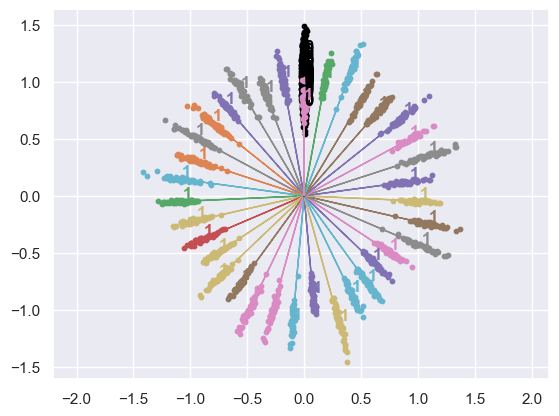

tensor([0.8466, 0.8195])


In [58]:
import torch
import math
import matplotlib.pyplot as plt
import random
sns.set_theme()

exps = []
for idx, theta_v in enumerate(torch.linspace(0, math.pi*2, steps=36)):
    x, tvs = create_datasets_and_task_vectors_2d(theta_v, sigma_perturb=0.01, sigma_scale=0.1, n_samples=50, sigma_mag=0.1)
    exps.append((x, tvs, theta_v))
    for t in range(2):
        color = 'black' if t == 0 else random.choice(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'])
        plt.scatter(x[:,t,0], x[:,t,1], s=10, color=color, label=f'Task {t}' if idx == 0 else None)
        plt.arrow(0, 0, tvs[t,0], tvs[t,1], head_width=0.01, head_length=0.01, color=color)
        plt.text(tvs[t,0], tvs[t,1], f"{t}", fontsize=12, color=color, ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()

# print dist of mags
print(torch.linalg.norm(tvs, dim=1))

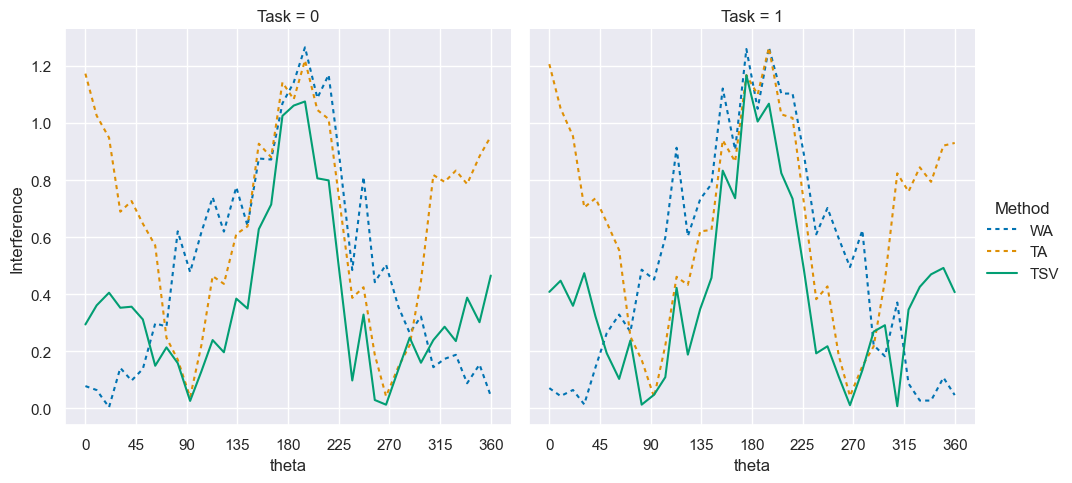

In [57]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd
sns.set_theme()
sns.set_palette("colorblind")

data = []
for x, tvs, theta_v in exps:
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    w_dwa1 = merge_dwa1(tvs)
    w_dwa2 = merge_dwa2(tvs)
    n_tasks = tvs.shape[0]
    theta_deg = torch.round(theta_v * 180 / math.pi).item()
    for t in range(n_tasks):
        data.append({'Task': t, 'Method': 'WA', 'Interference': interference_abs(w_wa, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TA', 'Interference': interference_abs(w_ta, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_abs(w_tsv, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA1', 'Interference': interference_abs(w_dwa1, tvs[t], x[:,t]), 'theta': theta_deg})
        # data.append({'Task': t, 'Method': 'DWA2', 'Interference': interference_abs(w_dwa2, tvs[t], x[:,t]), 'theta': theta_deg})
df = pd.DataFrame(data)

# Emphasize TSV in palette and marker
# g = sns.relplot(data=df, x='theta', y='Interference', kind='line', col='Task', style='Method',  hue='Method', dashes={"TSV": "", "DWA": "", "TA": (2, 2), "WA": (2, 2)})
g = sns.relplot(
    data=df, x="theta", y="Interference",
    kind="line", col="Task",
    hue="Method", style="Method",
    dashes={"TSV": "", "DWA1": "", "DWA2": "", "TA": (2, 2), "WA": (2, 2)}
)
g.set(xticks=list(range(0, 361, 45)))


### TSV 2-Task Partial Interference Sweep -- Matrix


Angle (degrees): 0.00
ta error: 1.00, 1.00
wa error: 0.00, 0.00
tsv error: 0.00, 0.00

Angle (degrees): 30.00
ta error: 0.87, 0.87
wa error: 0.07, 0.07
tsv error: 0.26, 0.26

Angle (degrees): 60.00
ta error: 0.50, 0.50
wa error: 0.25, 0.25
tsv error: 0.52, 0.52

Angle (degrees): 90.00
ta error: 0.00, 0.00
wa error: 0.50, 0.50
tsv error: 0.77, 0.77

Angle (degrees): 120.00
ta error: 0.50, 0.50
wa error: 0.75, 0.75
tsv error: 1.00, 1.00

Angle (degrees): 150.00
ta error: 0.87, 0.87
wa error: 0.93, 0.93
tsv error: 1.22, 1.22

Angle (degrees): 180.00
ta error: 1.00, 1.00
wa error: 1.00, 1.00
tsv error: 1.41, 1.41

Angle (degrees): 210.00
ta error: 0.87, 0.87
wa error: 0.93, 0.93
tsv error: 1.22, 1.22

Angle (degrees): 240.00
ta error: 0.50, 0.50
wa error: 0.75, 0.75
tsv error: 1.00, 1.00

Angle (degrees): 270.00
ta error: 0.00, 0.00
wa error: 0.50, 0.50
tsv error: 0.77, 0.77

Angle (degrees): 300.00
ta error: 0.50, 0.50
wa error: 0.25, 0.25
tsv error: 0.52, 0.52

Angle (degrees): 330.00
t

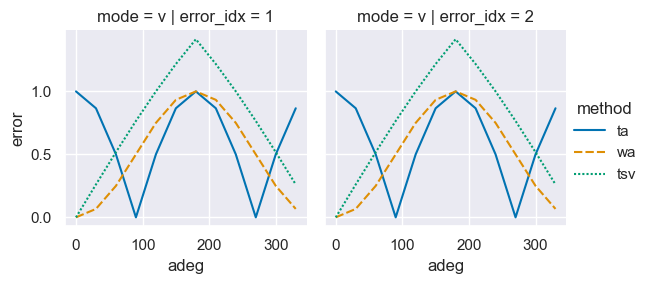

In [105]:
import torch
import math
import itertools
import pandas as pd

def get_projector_interference(theta_deg, verbose=False, mode='v', sigma_perturb=0.00, sigma_scale=0.0):
    theta_rads = theta_deg/360 * 2*math.pi  
    if mode == 'v':
        x, vs = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        u = torch.eye(2)[-1]
        u1, u2 = u, u
        v1, v2 = vs[0], vs[1]
    else:
        _, us = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        x, vs = create_datasets_and_task_vectors_2d(0, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=-1)
        u1, u2 = us[0], us[1]
        v1, v2 = vs[0], vs[1]

    uorth = compute_procrustes(torch.stack([u1, u2], dim=1)).T
    vorth = compute_procrustes(torch.stack([v1, v2], dim=1)).T

    u1o, u2o = uorth[0], uorth[1]
    v1o, v2o = vorth[0], vorth[1]

    w_targ_1 = torch.einsum('i,j->ij', u1, v1)
    w_targ_2 = torch.einsum('i,j->ij', u2, v2)
    w_ta = torch.einsum('i,j->ij', u1, v1) + torch.einsum('i,j->ij', u2, v2)
    w_wa = 1/2 * w_ta
    w_tsv = torch.einsum('i,j->ij', u1o, v1o) + torch.einsum('i,j->ij', u2o, v2o)


    if verbose:
        print(f"\nAngle (degrees): {theta_rads * 180 / math.pi:.2f}")
    errors_1 = {}
    errors_2 = {}
    for w, name in zip([w_ta, w_wa, w_tsv], ['ta', 'wa', 'tsv']):
        y_hat1 = w @ x[:, 0].T  # [D, N]
        y_hat2 = w @ x[:, 1].T  # [D, N]
        y1 = w_targ_1 @ x[:, 0].T  # [D, N]
        y2 = w_targ_2 @ x[:, 1].T  # [D, N]
        diff_1 = y1 - y_hat1
        diff_2 = y2 - y_hat2    
        # error_1 = diff_1.abs().mean().item()
        # error_2 = diff_2.abs().mean().item()
        error_1 = torch.linalg.norm(diff_1, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        error_2 = torch.linalg.norm(diff_2, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        errors_1[name] = error_1
        errors_2[name] = error_2
        if verbose:
            print(f"{name} error: {error_1:.2f}, {error_2:.2f}")
    return errors_1, errors_2


rows = []
for mode in ['v']:
    for adeg in range(0, 360, 30):
        # adeg = adeg.item()
        errors_1, errors_2 = get_projector_interference(adeg, mode=mode, verbose=True)
        rows.extend([
            {'adeg': adeg, 'method': 'ta', 'error': errors_1['ta'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_1['wa'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'tsv', 'error': errors_1['tsv'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'ta', 'error': errors_2['ta'], 'error_idx': 2, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_2['wa'], 'error_idx': 2, 'mode': mode}, 
            {'adeg': adeg, 'method': 'tsv', 'error': errors_2['tsv'], 'error_idx': 2, 'mode': mode},
        ])

# Plot the errors for both error_idx values side by side using seaborn
df = pd.DataFrame(rows)
sns.relplot(data=df, x='adeg', y='error', style='method', hue='method', col='error_idx', row='mode', kind='line', height=3, aspect=1)



In [106]:
w = torch.randn(2, 2)
u, s, vt = torch.linalg.svd(w)
print(s)
s1, s2 = s[0], s[1]

tensor([1.9253, 0.2392])


In [107]:
import itertools


def make_data_from_vecs(v, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000):
    N, D = v.shape
    # Create data
    x = v + torch.randn(n_samples, N, D) * sigma_perturb
    # Scale data
    x = x * (1.0 + torch.randn(n_samples, N, 1) * sigma_scale)
    return x

def rad2deg(rad):
    return rad * 180 / math.pi


n_steps = 36
theta_max = math.pi*2   
theta_range = torch.linspace(0, theta_max, steps=n_steps)

def make_interference_data(s1, s2, verbose=False):

    rows = []
    D = 2
    # theta_range = range(0, 360, 45)

    for theta_v, theta_u in itertools.product(theta_range, theta_range):

        # Create task mats
        u0, v0 = torch.eye(D)[-1], torch.eye(D)[0]
        u1, v1 = rot2d(theta_u) @ u0, rot2d(theta_v) @ v0

        # Create data
        xs = make_data_from_vecs(torch.stack([v0, v1], dim=0), sigma_perturb=0.05, sigma_scale=0.1, n_samples=50)


        # Create merged mats
        ## Target matrices
        w_targ_0 = torch.einsum('i,j->ij', u0 * s1, v0)
        w_targ_1 = torch.einsum('i,j->ij', u1 * s2, v1)

        ## Task Arithmetic & Weighted Average
        w_ta = torch.einsum('i,j->ij', u0 * s1,v0) + torch.einsum('i,j->ij', u1 * s2, v1)
        w_wa = 1/2 * w_ta

        ## TSV
        uorth = compute_procrustes(torch.stack([u0, u1], dim=1)).T
        vorth = compute_procrustes(torch.stack([v0, v1], dim=1)).T
        uo0, uo1 = uorth[0], uorth[1]
        vo0, vo1 = vorth[0], vorth[1]
        w_tsv = torch.einsum('i,j->ij', uo0 * s1, vo0) + torch.einsum('i,j->ij', uo1 * s2, vo1)
    

        errors = [
            {'name': 'ta', 'diff': w_ta - w_targ_0, "idx": 0},
            {'name': 'ta', 'diff': w_ta - w_targ_1, "idx": 1},
            {'name': 'wa', 'diff': w_wa - w_targ_0, "idx": 0},
            {'name': 'wa', 'diff': w_wa - w_targ_1, "idx": 1},
            {'name': 'tsv', 'diff': w_tsv - w_targ_0, "idx": 0},
            {'name': 'tsv', 'diff': w_tsv - w_targ_1, "idx": 1},
        ]

        if verbose:
            print("\n")
        for e in errors:
            theta_v_deg = rad2deg(theta_v).item() if isinstance(theta_v, torch.Tensor) else theta_v
            theta_u_deg = rad2deg(theta_u).item() if isinstance(theta_u, torch.Tensor) else theta_u
            e['theta_v'] = theta_v_deg
            e['theta_u'] = theta_u_deg
            if e['idx'] == 0:
                # (D, D) @ (D, N) -> (D, N) -> (N,) -> scalar
                e['error'] = torch.linalg.norm(e['diff'] @ xs[:, 0].T, ord=1, dim=0).mean().item()
            else:
                e['error'] = torch.linalg.norm(e['diff'] @ xs[:, 1].T, ord=1, dim=0).mean().item()

            spot_str = f"({int(theta_v_deg)}, {int(theta_u_deg)})"
            method_str = f"[{e['name']} {e['idx']}]"
            error_str = f"error: {e['error']:.5f}"  # 5 digits after decimal for error
            if verbose:
                print(f"{spot_str:>12} {method_str:<7} {error_str}")
        
        rows.extend(errors)

    # Plot the errors for both error_idx values side by side using seaborn
    df = pd.DataFrame(rows)
    return df


# Add scaling values
w = torch.randn(2, 2)
u, s, vt = torch.linalg.svd(w)
print(s)
# s1, s2 = s[0], s[1]
s1, s2 = 3, 3
df = make_interference_data(s1, s2)

tensor([1.1508, 0.1535])


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_93262/1271439594.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


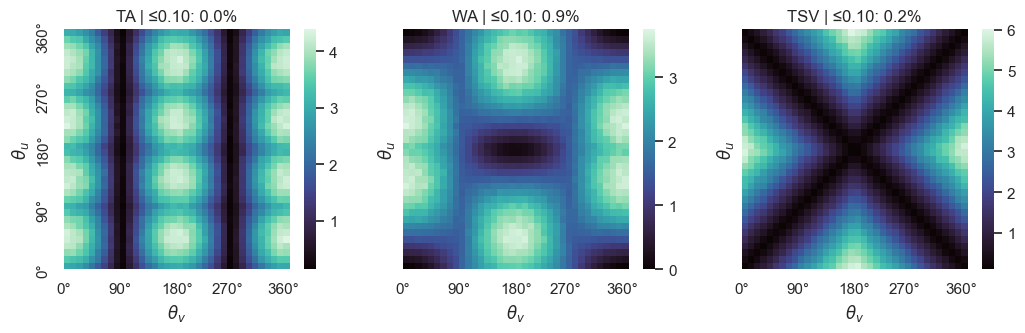

In [108]:
# import matplotlib.pyplot as plt
# import numpy as np
# methods = ["ta", "wa", "tsv"]
# idxs = [0, 1]

# fig, axes = plt.subplots(len(methods), 2, figsize=(10, 3*len(methods)), sharex=True, sharey=True)

# for ax, (m, i) in zip(axes.flat, itertools.product(methods, idxs)):
#     d = df[(df.name == m) & (df.idx == i)]
#     sns.histplot(
#         d, x="theta_v", y="theta_u",
#         weights="error", bins=n_steps,
#         pthresh=0, cmap="mako", cbar=True, ax=ax
#     )
#     ax.set(title=f"{m.upper()} (idx={i})", xlabel=r"$\theta_v$", ylabel=r"$\theta_u$")

# plt.tight_layout()
# plt.show()

methods = ["ta", "wa", "tsv"]
thr = 0.10
n_steps = len(theta_range)

tick_degs = np.arange(0, 361, 90)
ticks = np.round(tick_degs / 360 * (n_steps - 1)).astype(int)
labels = [f"{d}°" for d in tick_degs]

fig, axes = plt.subplots(
    1, len(methods),
    figsize=(3.5*len(methods), 3.5),
    sharex=True, sharey=True
)
for ax, m in zip(axes, methods):
    Z = df[(df.name == m) & (df.idx == 0)].error.values.reshape(n_steps, n_steps).T

    ok = Z < thr
    sns.heatmap(Z, cmap="mako", cbar=True, ax=ax)

    pct = ok.mean() * 100
    ax.set(
        title=f"{m.upper()} | ≤{thr:.2f}: {pct:.1f}%",
        xlabel=r"$\theta_v$", ylabel=r"$\theta_u$"
    )
    ax.invert_yaxis()
    ax.set(xticks=ticks, yticks=ticks,
           xticklabels=labels, yticklabels=labels)

plt.tight_layout()
plt.show()



In [ ]:
# WARNING: This takes a while to run
# Creates a dataframe for each (s1,s2) pair
from itertools import product
from tqdm import tqdm
import pandas as pd
import numpy as np

s = np.arange(0.0, 2.0 + 1e-9, 0.2)

dfs = []
for s2, s1 in tqdm(product(s, s), total=len(s)**2, desc="make_interference_data"):
    d = make_interference_data(s1, s2).copy()   # expects cols: name, idx, error, (theta_u/theta_v or flattened)
    d["s1"] = s1
    d["s2"] = s2
    dfs.append(d)

df_big = pd.concat(dfs, ignore_index=True)


make_interference_data:   0%|          | 0/121 [00:00<?, ?it/s]/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_83510/1520933175.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)
make_interference_data:   1%|          | 1/121 [00:00<00:45,  2.65it/s]/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_83510/1520933175.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)
make_interference_data:   2%|▏         | 2/121 [00:00<00:44,  2.66it/s]/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_83510/1520933175.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone()

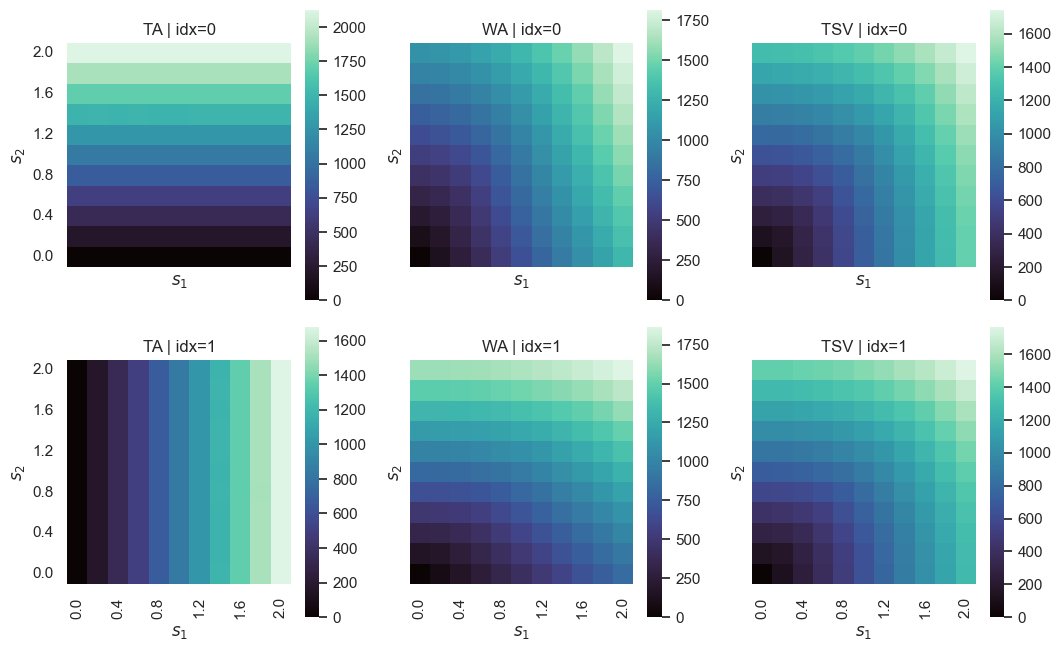

In [653]:
# Heatmaps for each index,method

methods = ["ta", "wa", "tsv"]
idxs = [0, 1]

s = np.sort(df_big["s1"].unique())
n = len(s)
ticks = np.arange(0, n, 2) + 0.5
labels = [f"{s[i]:.1f}" for i in range(0, n, 2)]

# aggregate once
df_sum = (
    df_big[df_big.idx.isin(idxs)]
    .groupby(["idx", "name", "s2", "s1"], sort=False)["error"]
    .sum()
    .reset_index(name="Zsum")
)

fig, axes = plt.subplots(
    len(idxs), len(methods),
    figsize=(3.6 * len(methods), 3.4 * len(idxs)),
    sharex=True, sharey=True
)

for r, idx in enumerate(idxs):
    for c, m in enumerate(methods):
        ax = axes[r, c]
        H = (
            df_sum[(df_sum.idx == idx) & (df_sum.name == m)]
            .pivot(index="s2", columns="s1", values="Zsum")
            .reindex(index=s, columns=s)
        )

        sns.heatmap(H, ax=ax, cmap="mako", square=True, cbar=True)

        ax.set_title(f"{m.upper()} | idx={idx}")
        ax.set_xlabel(r"$s_1$")
        ax.set_ylabel(r"$s_2$")
        ax.set(xticks=ticks, yticks=ticks, xticklabels=labels, yticklabels=labels)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()


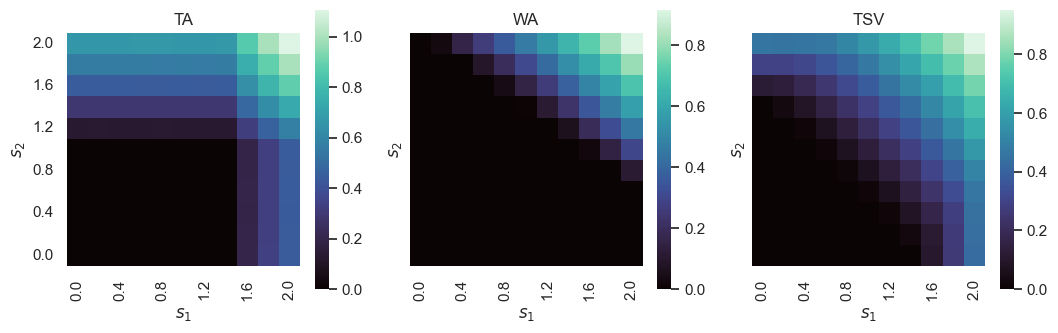

In [663]:
# Average over index, for each method

methods = ["ta", "wa", "tsv"]

s = np.sort(df_big["s1"].unique())
n = len(s)
ticks = np.arange(0, n, 2) + 0.5
labels = [f"{s[i]:.1f}" for i in range(0, n, 2)]

# 1) sum over theta-grid per idx
# df_sum = (
#     df_big
#     .groupby(["idx", "name", "s2", "s1"], sort=False)["error"]
#     .sum()
#     .reset_index(name="Zsum")
# )
thr = 1.5

df_sum = (
    df_big
    .assign(err_hi=lambda d: d.error.where(d.error > thr, 0.0))
    .groupby(["idx", "name", "s2", "s1"], sort=False)["err_hi"]
    .mean()
    .reset_index(name="Zsum")
)


# 2) average those sums across idx
df_avg = (
    df_sum
    .groupby(["name", "s2", "s1"], sort=False)["Zsum"]
    .mean()
    .reset_index(name="Zavg")
)

fig, axes = plt.subplots(
    1, len(methods),
    figsize=(3.6 * len(methods), 3.4),
    sharex=True, sharey=True
)

for ax, m in zip(axes, methods):
    H = (
        df_avg[df_avg.name == m]
        .pivot(index="s2", columns="s1", values="Zavg")
        .reindex(index=s, columns=s)
    )

    sns.heatmap(H, ax=ax, cmap="mako", square=True, cbar=True)

    ax.set(title=m.upper(), xlabel=r"$s_1$", ylabel=r"$s_2$")
    ax.set(xticks=ticks, yticks=ticks,
           xticklabels=labels, yticklabels=labels)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [139]:
# Compute Tr(E[ Wi @ xxT @ WjT])
theta_degs = 90
theta_rads = math.pi * theta_degs / 180
sigma_perturb, sigma_scale = 0.05, 0.1
d_task = 32
n_tasks = 8
x, v = create_datasets_and_task_vectors(n_tasks=n_tasks, d_task=d_task, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=100)
u = torch.stack([torch.eye(d_task)[-1] for _ in range(n_tasks)], dim=0)
print(x.shape, v.shape, u.shape)

cov = torch.zeros(n_tasks, d_task, d_task)
# For each task, compute the covariance matrix
for k in range(n_tasks):
    xk = x[:, k]
    N = xk.shape[0]
    cov[k] = xk.T @ xk / (N - 1)

traces = torch.zeros(n_tasks, n_tasks, n_tasks)
for k in range(n_tasks):
    for i,j in itertools.product(range(n_tasks), range(n_tasks)):
        wi = torch.einsum('i,j->ij', u[i], v[i])
        wj = torch.einsum('i,j->ij', u[j], v[j])
        traces[k, i, j] = torch.trace(wi @ cov[k] @ wj.T)

print("Traces:", traces.shape)

torch.Size([100, 8, 32]) torch.Size([8, 32]) torch.Size([8, 32])
Traces: torch.Size([8, 8, 8])


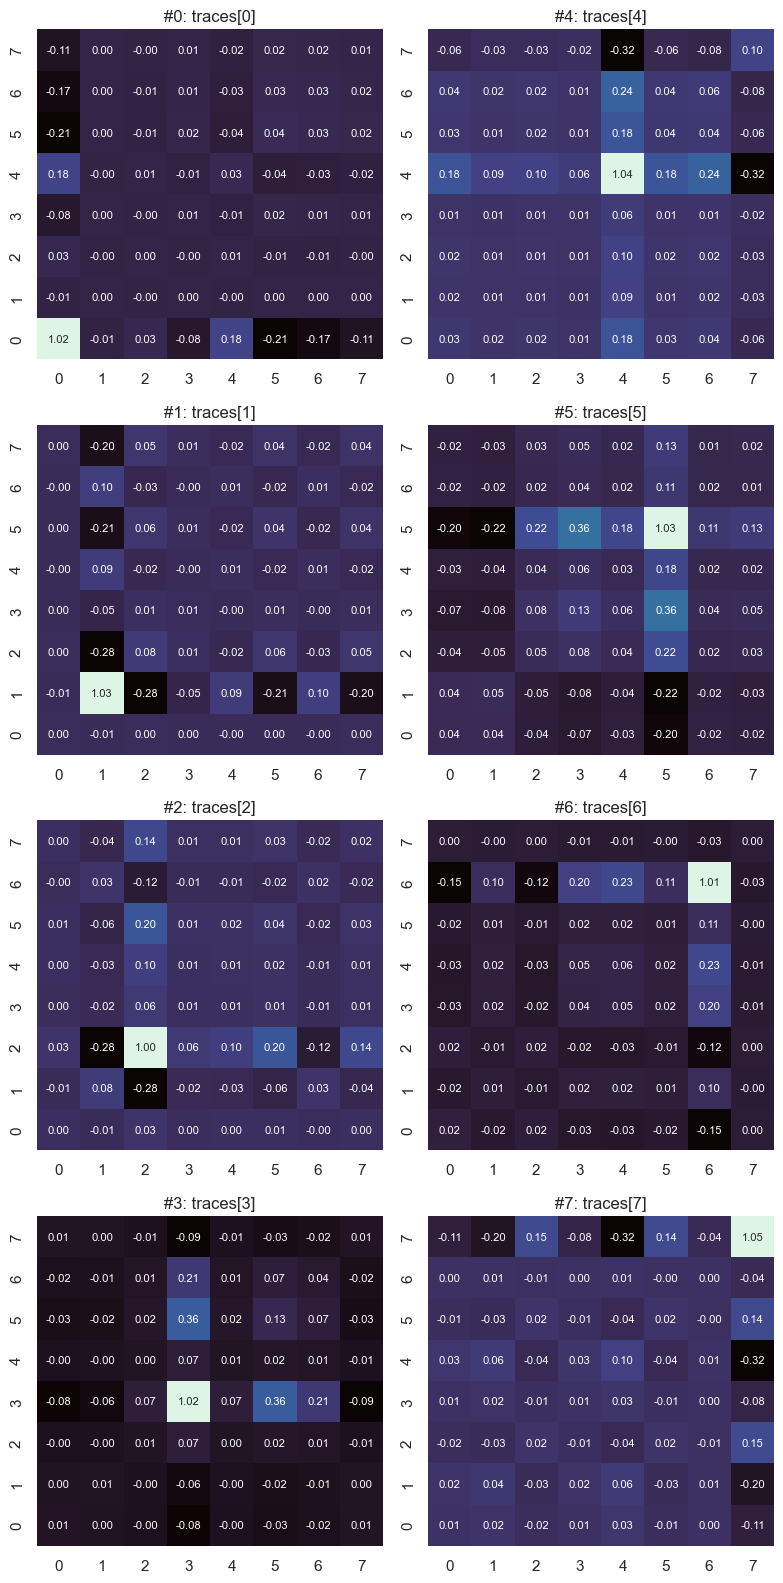

In [140]:
# Plot grid of heatmaps, looping over first dimension of traces
import seaborn as sns
import matplotlib.pyplot as plt

n_grid = traces.shape[0]
max_per_col = 4
ncols = (n_grid + max_per_col - 1) // max_per_col
nrows = min(max_per_col, n_grid)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for idx in range(n_grid):
    row = idx % max_per_col
    col = idx // max_per_col
    ax = axes[row, col]
    sns.heatmap(traces[idx], cmap="mako", ax=ax, annot=True, fmt=".2f", cbar=False, annot_kws={"size": 8})
    ax.set_title(f"#{idx}: traces[{idx}]")
    ax.invert_yaxis()

# Hide empty subplots, if any
for col in range(ncols):
    for row in range(nrows):
        panel_idx = col * max_per_col + row
        if panel_idx >= n_grid:
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## Real Data

### Helpers

In [ ]:
# Running covariance computation

import numpy as np


class OnlineCovariance:
    """
    A class to calculate the mean and the covariance matrix
    of the incrementally added, n-dimensional data.
    """

    def __init__(self, order):
        """
        Parameters
        ----------
        order: int, The order (=="number of features") of the incrementally added
        dataset and of the resulting covariance matrix.
        """
        self._order = order
        self._shape = (order, order)
        self._identity = np.identity(order)
        self._ones = np.ones(order)
        self._count = 0
        self._mean = np.zeros(order)
        self._cov = np.zeros(self._shape)

    @property
    def count(self):
        """
        int, The number of observations that has been added
        to this instance of OnlineCovariance.
        """
        return self._count

    @property
    def mean(self):
        """
        double, The mean of the added data.
        """
        return self._mean

    @property
    def cov(self):
        """
        array_like, The covariance matrix of the added data.
        """
        return self._cov

    @property
    def corrcoef(self):
        """
        array_like, The normalized covariance matrix of the added data.
        Consists of the Pearson Correlation Coefficients of the data's features.
        """
        if self._count < 1:
            return None
        variances = np.diagonal(self._cov)
        denomiator = np.sqrt(variances[np.newaxis, :] * variances[:, np.newaxis])
        return self._cov / denomiator

    def add(self, observation):
        """
        Add the given observation to this object.

        Parameters
        ----------
        observation: array_like, The observation to add.
        """
        if self._order != len(observation):
            raise ValueError(f"Observation to add must be of size {self._order}")

        self._count += 1
        delta_at_nMin1 = np.array(observation - self._mean)
        self._mean += delta_at_nMin1 / self._count
        weighted_delta_at_n = np.array(observation - self._mean) / self._count
        shp = (self._order, self._order)
        D_at_n = np.broadcast_to(weighted_delta_at_n, self._shape).T
        D = (delta_at_nMin1 * self._identity).dot(D_at_n.T)
        self._cov = self._cov * (self._count - 1) / self._count + D

    def merge(self, other):
        """
        Merges the current object and the given other object into a new OnlineCovariance object.

        Parameters
        ----------
        other: OnlineCovariance, The other OnlineCovariance to merge this object with.

        Returns
        -------
        OnlineCovariance
        """
        if other._order != self._order:
            raise ValueError(
                f"""
                   Cannot merge two OnlineCovariances with different orders.
                   ({self._order} != {other._order})
                   """
            )

        merged_cov = OnlineCovariance(self._order)
        merged_cov._count = self.count + other.count
        count_corr = (other.count * self.count) / merged_cov._count
        merged_cov._mean = (
            self.mean / other.count + other.mean / self.count
        ) * count_corr
        flat_mean_diff = self._mean - other._mean
        shp = (self._order, self._order)
        mean_diffs = np.broadcast_to(flat_mean_diff, self._shape).T
        merged_cov._cov = (
            self._cov * self.count
            + other._cov * other._count
            + mean_diffs * mean_diffs.T * count_corr
        ) / merged_cov.count
        return merged_cov



In [15]:
# Test OnlineCovariance
# Same calculations with OnlineCovariance
D = 4
ocov = OnlineCovariance(D)
for _ in range(100):
    x = torch.randn(D)
    ocov.add(x.numpy())

print("Covariance matrix:\n", np.round(ocov.cov, 2))
print("Mean:\n", np.round(ocov.mean, 2))

Covariance matrix:
 [[ 1.1  -0.13  0.16 -0.1 ]
 [-0.13  0.76 -0.05 -0.03]
 [ 0.16 -0.05  1.11 -0.02]
 [-0.1  -0.03 -0.02  0.96]]
Mean:
 [-0.04  0.09  0.06 -0.05]


### Save layer-wise covariance

In [ ]:
# Load model for Cars
import torch
import certifi
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"

from src.datasets.registry import get_dataset
from src.datasets.common import get_dataloader_v2, maybe_dictionarize
from src.models.modeling import ImageClassifier, ImageEncoder
from src.models.heads import build_classification_head
from src.datasets.templates import get_templates


# dataset_name = "CIFAR10"
# batch_size = 32
# template = get_templates(dataset_name)
# data_location = "datasets"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_name = "ViT-B-16"

# # Build model
# image_encoder = ImageEncoder(model_name, keep_lang=True)

# classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
# model = ImageClassifier(image_encoder, classification_head)

# batch_size = 1
# dataset = get_dataset(
#     dataset_name,
#     model.val_preprocess,
#     location=data_location,
#     batch_size=batch_size,
# )
# dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Building classification head.


100%|██████████| 10/10 [00:01<00:00,  6.90it/s]


zeroshot shape, Ptorch.Size([10, 512])


In [ ]:
# dataset_name = "CIFAR10"
dataset_name = "Cars"
batch_size = 32
template = get_templates(dataset_name)
data_location = "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ViT-B-16"

# Build model
image_encoder = ImageEncoder(model_name, keep_lang=True)
classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
model = ImageClassifier(image_encoder, classification_head)

dataset = get_dataset(
    dataset_name,
    model.val_preprocess,
    location=data_location,
    batch_size=batch_size,
)
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

In [ ]:
# Get finetuned params
from src.models.task_vectors import NonLinearTaskVector

def add_tv_to_model(model, tv):
    new_dict = {}
    skipped = []
    added = []
    pt_dict = model.state_dict()
    tv_dict = tv.vector
    for k in pt_dict.keys():
        if k in tv_dict:
            new_dict[k] = pt_dict[k].to(device) + tv_dict[k].to(device)
            added.append(k)
        else:
            skipped.append(k)
            new_dict[k] = pt_dict[k]
    return new_dict, added, skipped



MODELS_ROOT = os.path.expanduser("models/checkpoints")

# Calculate task vectors
pretrained_checkpoint = f"{MODELS_ROOT}/{model_name}/MNISTVal/nonlinear_zeroshot.pt"
finetuned_checkpoint = f"{MODELS_ROOT}/{model_name}/{dataset_name}Val/nonlinear_finetuned.pt"
tv = NonLinearTaskVector(model_name, pretrained_checkpoint, finetuned_checkpoint)

# Load tv into model
new_dict, added, skipped = add_tv_to_model(model.image_encoder, tv)
model.image_encoder.load_state_dict(new_dict)
print("Added layers:", added)
print("Skipped layers:", skipped)


In [5]:
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=1, device=device)

In [ ]:
# Need to save mats (T, Do, Di) and acts (T, N, Do)
# Pass single batch and measure mean and std of all activations
data = maybe_dictionarize(next(iter(dataloader)))
x = data['images']
model.to(device)
x = x.to(device)
out = model(x)
print("Output shape:", out.shape)
print("Device:", out.device)
# >>> out.shape
# torch.Size([32, 1000])

In [ ]:
import torch
import itertools

# Compute running covariance of activations
stats = {}  # layer_name -> hook_result
handles = []  # references to hooks
MAX_HOOKS = 20
MAX_BATCHES = 20

def compute_stats(inp, out):
    # Compute stat given input, output of the layer
    return x.mean().item(), x.std(unbiased=False).item(), tuple(x.shape)

def hook(name):
    # Hook gets (module, input, output)
    def h(mod, _inp, out):
        # print("out.shape", out.shape)
        inp = _inp[0]
        if torch.is_tensor(inp):
            print("inp.shape", inp.shape)
            B, T, D = inp.shape
            if name not in stats:
                ocov = OnlineCovariance(D)
                stats[name] = ocov
            ocov = stats[name]
            for i in range(B):
                j = torch.randint(0, T, (1,)).item()
                v = inp[i, j].cpu().detach().numpy()
                # normalize v
                # v = v / np.linalg.norm(v)
                ocov.add(v)
            stats[name] = ocov
    return h

num_registered = 0
for i, (name, m) in enumerate(model.named_modules()):
    if isinstance(m, torch.nn.Linear):
        print("Registering hook for", name)
        h = m.register_forward_hook(hook(name))
        handles.append(h)
        if num_registered > MAX_HOOKS:
            break
        num_registered += 1

model.to(device)
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        print("Processing batch", i)
        x = maybe_dictionarize(batch)["images"]
        model(x.to(device))
        if i > MAX_BATCHES:
            break

In [ ]:
# Unregister hooks from model
for h in handles:
    h.remove()

In [ ]:
import pickle

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

covs = {}
means = {}
for s in stats:
    c = stats[s].cov
    m = stats[s].mean
    print(s, c.shape)
    covs[s] = c

to_save = {
    "model": model_name,
    "dataset": dataset_name,
    "covs": covs,
    "means": means,
}

with open(os.path.join(results_dir, f"covs_{dataset_name}.pkl"), "wb") as f:
    pickle.dump(to_save, f)


### Save layer-wise mats

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )


    # if len(task_vectors[0].vector[layer_name].shape) == 2 and "text_projection" not in layer_name:
    #     if task_vectors[0].vector[layer_name].min() == task_vectors[0].vector[layer_name].max() == 0:
    #         continue

# mats = torch.stack(mats)

In [ ]:
# Pull out single matrix
mats = {}
for layer_name in task_vectors[0].vector:
    for tv in task_vectors:
        if layer_name not in mats:
            mats[layer_name] = []
        mats[layer_name].append(tv.vector[layer_name])

# Now stack
for layer_name in mats:
    mats[layer_name] = torch.stack(mats[layer_name])


In [ ]:
# keys = list(set(k.split(".npy")[0].replace("cov_", "") for k in os.listdir(covs_dir)))
# keys = sorted(keys)
# keys
# # Save as a dict using pickle

In [ ]:
# # Build a dict of mats
# mats = {}
# for layer_name in keys:
#      for tv in task_vectors:
#           k = layer_name + ".weight"
#           print("adding", k)
#           # mats[](tv.vector[k])
#           if not k in mats:
#                mats[k] = []
#           mats[k].append(tv.vector[k])

# for k in mats:
#      mats[k] = torch.stack(mats[k])

In [ ]:
# Save as a dict using pickle
import pickle
import os.path as osp
mats_dir = "results"
os.makedirs(mats_dir, exist_ok=True)
save_dict = {
    "datasets": datasets,
    "weights": {k: v.numpy() for k, v in mats.items()}
}
with open(osp.join(mats_dir, f"mats.pkl"), "wb") as f:
    pickle.dump(save_dict, f)

In [ ]:
# Load as a dict
import pickle
import os.path as osp
mats_dir = "results/mats"
with open(osp.join(mats_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)
mats_dict['weights'].keys()


### Analyze task vector orthogonality

dict_keys(['model.visual.transformer.resblocks.0.mlp.c_fc', 'model.visual.transformer.resblocks.0.mlp.c_proj', 'model.visual.transformer.resblocks.1.mlp.c_fc', 'model.visual.transformer.resblocks.1.mlp.c_proj', 'model.visual.transformer.resblocks.2.mlp.c_fc', 'model.visual.transformer.resblocks.2.mlp.c_proj', 'model.visual.transformer.resblocks.3.mlp.c_fc', 'model.visual.transformer.resblocks.3.mlp.c_proj'])
dict_keys(['model.visual.transformer.resblocks.0.mlp.c_fc', 'model.visual.transformer.resblocks.0.mlp.c_proj', 'model.visual.transformer.resblocks.1.mlp.c_fc', 'model.visual.transformer.resblocks.1.mlp.c_proj', 'model.visual.transformer.resblocks.2.mlp.c_fc', 'model.visual.transformer.resblocks.2.mlp.c_proj', 'model.visual.transformer.resblocks.3.mlp.c_fc', 'model.visual.transformer.resblocks.3.mlp.c_proj'])


<Axes: >

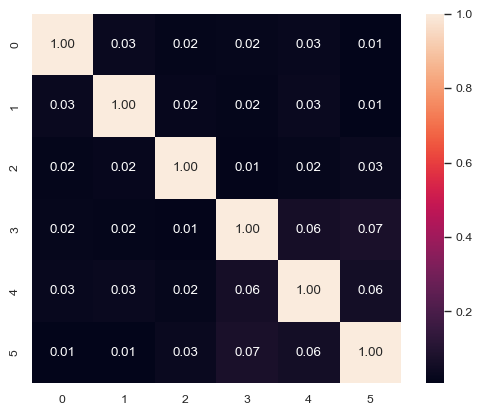

In [55]:
import pickle
import os.path as osp
results_dir = "results"

with open(osp.join(results_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)

mats = mats_dict['weights']
mats = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in mats.items()}

print(covs.keys())
print(mats.keys())
k = 'model.visual.transformer.resblocks.0.mlp.c_fc'
m = torch.from_numpy(mats[k])
m_tilde = m / torch.linalg.norm(m, dim=-1, keepdim=True)
z = torch.einsum('toi,loi->otl', m_tilde, m_tilde)
sns.heatmap(z.mean(dim=0).numpy(), cmap="rocket", square=True, annot=True, fmt=".2f")

In [45]:
import torch
linear = torch.nn.Linear(in_features=100, out_features=10)
linear.weight.shape

torch.Size([10, 100])

### Analyze task data orthogonality

In [ ]:
import pickle
import os
import os.path as osp
import torch
results_dir = "results"


# 1. Load layer covariances for each task
task_list = ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN'][::-1]
dataset_covs = {}
for filename in [f for f in os.listdir(results_dir) if "covs" in f]:
    with open(osp.join(results_dir, filename), "rb") as f:
        covs_dict_i = pickle.load(f)
        dataset_name = filename.split('covs_')[1].split(".pkl")[0]
        dataset_covs[dataset_name] = covs_dict_i['covs']
# order covariances
dataset_covs = {
    k: dataset_covs[k]
    for k in task_list
    if k in dataset_covs
}
print("datasets_covs:", dataset_covs.keys())

# 2. Load layer transforms for each task (already stacked)
with open(osp.join(results_dir, f"mats.pkl"), "rb") as f:
    mats_dict = pickle.load(f)
mats = mats_dict['weights']
mats_task_names = mats_dict['datasets']

# Order mats
# indices that reorder current -> desired
mats_task_order = [mats_task_names.index(t) for t in task_list if t in mats_task_names]
print("mask_task_order:", mats_task_order)
# reorder each matrix
for k in mats:
    mats[k] = mats[k][mats_task_order]

# Fix keys names
# remove image_encoder. and .weight from keys
mats = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in mats.items()}
for dataset_name in dataset_covs:
    covs = dataset_covs[dataset_name]
    dataset_covs[dataset_name] = {k.replace("image_encoder.", "").replace(".weight", ""): v for k, v in covs.items()}
print("Covs:", covs.keys())
print("Mats:", mats.keys())

datasets_covs: dict_keys(['SVHN', 'GTSRB', 'EuroSAT', 'DTD', 'Cars'])


In [22]:
print(len(dataset_covs['Cars']))
k0 = next(iter(dataset_covs['Cars'].keys()))
print(dataset_covs['Cars'][k0].shape)
added_layers = ['model.positional_embedding', 'model.text_projection', 'model.logit_scale', 'model.visual.class_embedding', 'model.visual.positional_embedding', 'model.visual.proj', 'model.visual.conv1.weight', 'model.visual.ln_pre.weight', 'model.visual.ln_pre.bias', 'model.visual.transformer.resblocks.0.ln_1.weight', 'model.visual.transformer.resblocks.0.ln_1.bias', 'model.visual.transformer.resblocks.0.attn.in_proj_weight', 'model.visual.transformer.resblocks.0.attn.in_proj_bias', 'model.visual.transformer.resblocks.0.attn.out_proj.weight', 'model.visual.transformer.resblocks.0.attn.out_proj.bias', 'model.visual.transformer.resblocks.0.ln_2.weight', 'model.visual.transformer.resblocks.0.ln_2.bias', 'model.visual.transformer.resblocks.0.mlp.c_fc.weight', 'model.visual.transformer.resblocks.0.mlp.c_fc.bias', 'model.visual.transformer.resblocks.0.mlp.c_proj.weight', 'model.visual.transformer.resblocks.0.mlp.c_proj.bias', 'model.visual.transformer.resblocks.1.ln_1.weight', 'model.visual.transformer.resblocks.1.ln_1.bias', 'model.visual.transformer.resblocks.1.attn.in_proj_weight', 'model.visual.transformer.resblocks.1.attn.in_proj_bias', 'model.visual.transformer.resblocks.1.attn.out_proj.weight', 'model.visual.transformer.resblocks.1.attn.out_proj.bias', 'model.visual.transformer.resblocks.1.ln_2.weight', 'model.visual.transformer.resblocks.1.ln_2.bias', 'model.visual.transformer.resblocks.1.mlp.c_fc.weight', 'model.visual.transformer.resblocks.1.mlp.c_fc.bias', 'model.visual.transformer.resblocks.1.mlp.c_proj.weight', 'model.visual.transformer.resblocks.1.mlp.c_proj.bias', 'model.visual.transformer.resblocks.2.ln_1.weight', 'model.visual.transformer.resblocks.2.ln_1.bias', 'model.visual.transformer.resblocks.2.attn.in_proj_weight', 'model.visual.transformer.resblocks.2.attn.in_proj_bias', 'model.visual.transformer.resblocks.2.attn.out_proj.weight', 'model.visual.transformer.resblocks.2.attn.out_proj.bias', 'model.visual.transformer.resblocks.2.ln_2.weight', 'model.visual.transformer.resblocks.2.ln_2.bias', 'model.visual.transformer.resblocks.2.mlp.c_fc.weight', 'model.visual.transformer.resblocks.2.mlp.c_fc.bias', 'model.visual.transformer.resblocks.2.mlp.c_proj.weight', 'model.visual.transformer.resblocks.2.mlp.c_proj.bias', 'model.visual.transformer.resblocks.3.ln_1.weight', 'model.visual.transformer.resblocks.3.ln_1.bias', 'model.visual.transformer.resblocks.3.attn.in_proj_weight', 'model.visual.transformer.resblocks.3.attn.in_proj_bias', 'model.visual.transformer.resblocks.3.attn.out_proj.weight', 'model.visual.transformer.resblocks.3.attn.out_proj.bias', 'model.visual.transformer.resblocks.3.ln_2.weight', 'model.visual.transformer.resblocks.3.ln_2.bias', 'model.visual.transformer.resblocks.3.mlp.c_fc.weight', 'model.visual.transformer.resblocks.3.mlp.c_fc.bias', 'model.visual.transformer.resblocks.3.mlp.c_proj.weight', 'model.visual.transformer.resblocks.3.mlp.c_proj.bias', 'model.visual.transformer.resblocks.4.ln_1.weight', 'model.visual.transformer.resblocks.4.ln_1.bias', 'model.visual.transformer.resblocks.4.attn.in_proj_weight', 'model.visual.transformer.resblocks.4.attn.in_proj_bias', 'model.visual.transformer.resblocks.4.attn.out_proj.weight', 'model.visual.transformer.resblocks.4.attn.out_proj.bias', 'model.visual.transformer.resblocks.4.ln_2.weight', 'model.visual.transformer.resblocks.4.ln_2.bias', 'model.visual.transformer.resblocks.4.mlp.c_fc.weight', 'model.visual.transformer.resblocks.4.mlp.c_fc.bias', 'model.visual.transformer.resblocks.4.mlp.c_proj.weight', 'model.visual.transformer.resblocks.4.mlp.c_proj.bias', 'model.visual.transformer.resblocks.5.ln_1.weight', 'model.visual.transformer.resblocks.5.ln_1.bias', 'model.visual.transformer.resblocks.5.attn.in_proj_weight', 'model.visual.transformer.resblocks.5.attn.in_proj_bias', 'model.visual.transformer.resblocks.5.attn.out_proj.weight', 'model.visual.transformer.resblocks.5.attn.out_proj.bias', 'model.visual.transformer.resblocks.5.ln_2.weight', 'model.visual.transformer.resblocks.5.ln_2.bias', 'model.visual.transformer.resblocks.5.mlp.c_fc.weight', 'model.visual.transformer.resblocks.5.mlp.c_fc.bias', 'model.visual.transformer.resblocks.5.mlp.c_proj.weight', 'model.visual.transformer.resblocks.5.mlp.c_proj.bias', 'model.visual.transformer.resblocks.6.ln_1.weight', 'model.visual.transformer.resblocks.6.ln_1.bias', 'model.visual.transformer.resblocks.6.attn.in_proj_weight', 'model.visual.transformer.resblocks.6.attn.in_proj_bias', 'model.visual.transformer.resblocks.6.attn.out_proj.weight', 'model.visual.transformer.resblocks.6.attn.out_proj.bias', 'model.visual.transformer.resblocks.6.ln_2.weight', 'model.visual.transformer.resblocks.6.ln_2.bias', 'model.visual.transformer.resblocks.6.mlp.c_fc.weight', 'model.visual.transformer.resblocks.6.mlp.c_fc.bias', 'model.visual.transformer.resblocks.6.mlp.c_proj.weight', 'model.visual.transformer.resblocks.6.mlp.c_proj.bias', 'model.visual.transformer.resblocks.7.ln_1.weight', 'model.visual.transformer.resblocks.7.ln_1.bias', 'model.visual.transformer.resblocks.7.attn.in_proj_weight', 'model.visual.transformer.resblocks.7.attn.in_proj_bias', 'model.visual.transformer.resblocks.7.attn.out_proj.weight', 'model.visual.transformer.resblocks.7.attn.out_proj.bias', 'model.visual.transformer.resblocks.7.ln_2.weight', 'model.visual.transformer.resblocks.7.ln_2.bias', 'model.visual.transformer.resblocks.7.mlp.c_fc.weight', 'model.visual.transformer.resblocks.7.mlp.c_fc.bias', 'model.visual.transformer.resblocks.7.mlp.c_proj.weight', 'model.visual.transformer.resblocks.7.mlp.c_proj.bias', 'model.visual.transformer.resblocks.8.ln_1.weight', 'model.visual.transformer.resblocks.8.ln_1.bias', 'model.visual.transformer.resblocks.8.attn.in_proj_weight', 'model.visual.transformer.resblocks.8.attn.in_proj_bias', 'model.visual.transformer.resblocks.8.attn.out_proj.weight', 'model.visual.transformer.resblocks.8.attn.out_proj.bias', 'model.visual.transformer.resblocks.8.ln_2.weight', 'model.visual.transformer.resblocks.8.ln_2.bias', 'model.visual.transformer.resblocks.8.mlp.c_fc.weight', 'model.visual.transformer.resblocks.8.mlp.c_fc.bias', 'model.visual.transformer.resblocks.8.mlp.c_proj.weight', 'model.visual.transformer.resblocks.8.mlp.c_proj.bias', 'model.visual.transformer.resblocks.9.ln_1.weight', 'model.visual.transformer.resblocks.9.ln_1.bias', 'model.visual.transformer.resblocks.9.attn.in_proj_weight', 'model.visual.transformer.resblocks.9.attn.in_proj_bias', 'model.visual.transformer.resblocks.9.attn.out_proj.weight', 'model.visual.transformer.resblocks.9.attn.out_proj.bias', 'model.visual.transformer.resblocks.9.ln_2.weight', 'model.visual.transformer.resblocks.9.ln_2.bias', 'model.visual.transformer.resblocks.9.mlp.c_fc.weight', 'model.visual.transformer.resblocks.9.mlp.c_fc.bias', 'model.visual.transformer.resblocks.9.mlp.c_proj.weight', 'model.visual.transformer.resblocks.9.mlp.c_proj.bias', 'model.visual.transformer.resblocks.10.ln_1.weight', 'model.visual.transformer.resblocks.10.ln_1.bias', 'model.visual.transformer.resblocks.10.attn.in_proj_weight', 'model.visual.transformer.resblocks.10.attn.in_proj_bias', 'model.visual.transformer.resblocks.10.attn.out_proj.weight', 'model.visual.transformer.resblocks.10.attn.out_proj.bias', 'model.visual.transformer.resblocks.10.ln_2.weight', 'model.visual.transformer.resblocks.10.ln_2.bias', 'model.visual.transformer.resblocks.10.mlp.c_fc.weight', 'model.visual.transformer.resblocks.10.mlp.c_fc.bias', 'model.visual.transformer.resblocks.10.mlp.c_proj.weight', 'model.visual.transformer.resblocks.10.mlp.c_proj.bias', 'model.visual.transformer.resblocks.11.ln_1.weight', 'model.visual.transformer.resblocks.11.ln_1.bias', 'model.visual.transformer.resblocks.11.attn.in_proj_weight', 'model.visual.transformer.resblocks.11.attn.in_proj_bias', 'model.visual.transformer.resblocks.11.attn.out_proj.weight', 'model.visual.transformer.resblocks.11.attn.out_proj.bias', 'model.visual.transformer.resblocks.11.ln_2.weight', 'model.visual.transformer.resblocks.11.ln_2.bias', 'model.visual.transformer.resblocks.11.mlp.c_fc.weight', 'model.visual.transformer.resblocks.11.mlp.c_fc.bias', 'model.visual.transformer.resblocks.11.mlp.c_proj.weight', 'model.visual.transformer.resblocks.11.mlp.c_proj.bias', 'model.visual.ln_post.weight', 'model.visual.ln_post.bias', 'model.token_embedding.weight', 'model.ln_final.weight', 'model.ln_final.bias']
skipped_layers = ['model.transformer.resblocks.0.ln_1.weight', 'model.transformer.resblocks.0.ln_1.bias', 'model.transformer.resblocks.0.attn.in_proj_weight', 'model.transformer.resblocks.0.attn.in_proj_bias', 'model.transformer.resblocks.0.attn.out_proj.weight', 'model.transformer.resblocks.0.attn.out_proj.bias', 'model.transformer.resblocks.0.ln_2.weight', 'model.transformer.resblocks.0.ln_2.bias', 'model.transformer.resblocks.0.mlp.c_fc.weight', 'model.transformer.resblocks.0.mlp.c_fc.bias', 'model.transformer.resblocks.0.mlp.c_proj.weight', 'model.transformer.resblocks.0.mlp.c_proj.bias', 'model.transformer.resblocks.1.ln_1.weight', 'model.transformer.resblocks.1.ln_1.bias', 'model.transformer.resblocks.1.attn.in_proj_weight', 'model.transformer.resblocks.1.attn.in_proj_bias', 'model.transformer.resblocks.1.attn.out_proj.weight', 'model.transformer.resblocks.1.attn.out_proj.bias', 'model.transformer.resblocks.1.ln_2.weight', 'model.transformer.resblocks.1.ln_2.bias', 'model.transformer.resblocks.1.mlp.c_fc.weight', 'model.transformer.resblocks.1.mlp.c_fc.bias', 'model.transformer.resblocks.1.mlp.c_proj.weight', 'model.transformer.resblocks.1.mlp.c_proj.bias', 'model.transformer.resblocks.2.ln_1.weight', 'model.transformer.resblocks.2.ln_1.bias', 'model.transformer.resblocks.2.attn.in_proj_weight', 'model.transformer.resblocks.2.attn.in_proj_bias', 'model.transformer.resblocks.2.attn.out_proj.weight', 'model.transformer.resblocks.2.attn.out_proj.bias', 'model.transformer.resblocks.2.ln_2.weight', 'model.transformer.resblocks.2.ln_2.bias', 'model.transformer.resblocks.2.mlp.c_fc.weight', 'model.transformer.resblocks.2.mlp.c_fc.bias', 'model.transformer.resblocks.2.mlp.c_proj.weight', 'model.transformer.resblocks.2.mlp.c_proj.bias', 'model.transformer.resblocks.3.ln_1.weight', 'model.transformer.resblocks.3.ln_1.bias', 'model.transformer.resblocks.3.attn.in_proj_weight', 'model.transformer.resblocks.3.attn.in_proj_bias', 'model.transformer.resblocks.3.attn.out_proj.weight', 'model.transformer.resblocks.3.attn.out_proj.bias', 'model.transformer.resblocks.3.ln_2.weight', 'model.transformer.resblocks.3.ln_2.bias', 'model.transformer.resblocks.3.mlp.c_fc.weight', 'model.transformer.resblocks.3.mlp.c_fc.bias', 'model.transformer.resblocks.3.mlp.c_proj.weight', 'model.transformer.resblocks.3.mlp.c_proj.bias', 'model.transformer.resblocks.4.ln_1.weight', 'model.transformer.resblocks.4.ln_1.bias', 'model.transformer.resblocks.4.attn.in_proj_weight', 'model.transformer.resblocks.4.attn.in_proj_bias', 'model.transformer.resblocks.4.attn.out_proj.weight', 'model.transformer.resblocks.4.attn.out_proj.bias', 'model.transformer.resblocks.4.ln_2.weight', 'model.transformer.resblocks.4.ln_2.bias', 'model.transformer.resblocks.4.mlp.c_fc.weight', 'model.transformer.resblocks.4.mlp.c_fc.bias', 'model.transformer.resblocks.4.mlp.c_proj.weight', 'model.transformer.resblocks.4.mlp.c_proj.bias', 'model.transformer.resblocks.5.ln_1.weight', 'model.transformer.resblocks.5.ln_1.bias', 'model.transformer.resblocks.5.attn.in_proj_weight', 'model.transformer.resblocks.5.attn.in_proj_bias', 'model.transformer.resblocks.5.attn.out_proj.weight', 'model.transformer.resblocks.5.attn.out_proj.bias', 'model.transformer.resblocks.5.ln_2.weight', 'model.transformer.resblocks.5.ln_2.bias', 'model.transformer.resblocks.5.mlp.c_fc.weight', 'model.transformer.resblocks.5.mlp.c_fc.bias', 'model.transformer.resblocks.5.mlp.c_proj.weight', 'model.transformer.resblocks.5.mlp.c_proj.bias', 'model.transformer.resblocks.6.ln_1.weight', 'model.transformer.resblocks.6.ln_1.bias', 'model.transformer.resblocks.6.attn.in_proj_weight', 'model.transformer.resblocks.6.attn.in_proj_bias', 'model.transformer.resblocks.6.attn.out_proj.weight', 'model.transformer.resblocks.6.attn.out_proj.bias', 'model.transformer.resblocks.6.ln_2.weight', 'model.transformer.resblocks.6.ln_2.bias', 'model.transformer.resblocks.6.mlp.c_fc.weight', 'model.transformer.resblocks.6.mlp.c_fc.bias', 'model.transformer.resblocks.6.mlp.c_proj.weight', 'model.transformer.resblocks.6.mlp.c_proj.bias', 'model.transformer.resblocks.7.ln_1.weight', 'model.transformer.resblocks.7.ln_1.bias', 'model.transformer.resblocks.7.attn.in_proj_weight', 'model.transformer.resblocks.7.attn.in_proj_bias', 'model.transformer.resblocks.7.attn.out_proj.weight', 'model.transformer.resblocks.7.attn.out_proj.bias', 'model.transformer.resblocks.7.ln_2.weight', 'model.transformer.resblocks.7.ln_2.bias', 'model.transformer.resblocks.7.mlp.c_fc.weight', 'model.transformer.resblocks.7.mlp.c_fc.bias', 'model.transformer.resblocks.7.mlp.c_proj.weight', 'model.transformer.resblocks.7.mlp.c_proj.bias', 'model.transformer.resblocks.8.ln_1.weight', 'model.transformer.resblocks.8.ln_1.bias', 'model.transformer.resblocks.8.attn.in_proj_weight', 'model.transformer.resblocks.8.attn.in_proj_bias', 'model.transformer.resblocks.8.attn.out_proj.weight', 'model.transformer.resblocks.8.attn.out_proj.bias', 'model.transformer.resblocks.8.ln_2.weight', 'model.transformer.resblocks.8.ln_2.bias', 'model.transformer.resblocks.8.mlp.c_fc.weight', 'model.transformer.resblocks.8.mlp.c_fc.bias', 'model.transformer.resblocks.8.mlp.c_proj.weight', 'model.transformer.resblocks.8.mlp.c_proj.bias', 'model.transformer.resblocks.9.ln_1.weight', 'model.transformer.resblocks.9.ln_1.bias', 'model.transformer.resblocks.9.attn.in_proj_weight', 'model.transformer.resblocks.9.attn.in_proj_bias', 'model.transformer.resblocks.9.attn.out_proj.weight', 'model.transformer.resblocks.9.attn.out_proj.bias', 'model.transformer.resblocks.9.ln_2.weight', 'model.transformer.resblocks.9.ln_2.bias', 'model.transformer.resblocks.9.mlp.c_fc.weight', 'model.transformer.resblocks.9.mlp.c_fc.bias', 'model.transformer.resblocks.9.mlp.c_proj.weight', 'model.transformer.resblocks.9.mlp.c_proj.bias', 'model.transformer.resblocks.10.ln_1.weight', 'model.transformer.resblocks.10.ln_1.bias', 'model.transformer.resblocks.10.attn.in_proj_weight', 'model.transformer.resblocks.10.attn.in_proj_bias', 'model.transformer.resblocks.10.attn.out_proj.weight', 'model.transformer.resblocks.10.attn.out_proj.bias', 'model.transformer.resblocks.10.ln_2.weight', 'model.transformer.resblocks.10.ln_2.bias', 'model.transformer.resblocks.10.mlp.c_fc.weight', 'model.transformer.resblocks.10.mlp.c_fc.bias', 'model.transformer.resblocks.10.mlp.c_proj.weight', 'model.transformer.resblocks.10.mlp.c_proj.bias', 'model.transformer.resblocks.11.ln_1.weight', 'model.transformer.resblocks.11.ln_1.bias', 'model.transformer.resblocks.11.attn.in_proj_weight', 'model.transformer.resblocks.11.attn.in_proj_bias', 'model.transformer.resblocks.11.attn.out_proj.weight', 'model.transformer.resblocks.11.attn.out_proj.bias', 'model.transformer.resblocks.11.ln_2.weight', 'model.transformer.resblocks.11.ln_2.bias', 'model.transformer.resblocks.11.mlp.c_fc.weight', 'model.transformer.resblocks.11.mlp.c_fc.bias', 'model.transformer.resblocks.11.mlp.c_proj.weight', 'model.transformer.resblocks.11.mlp.c_proj.bias']


14
(768, 768)


In [23]:
import itertools
N_TASKS_COV = len(dataset_covs)
N_TASKS_MAT = len(mats[list(mats.keys())[0]])
N_LAYERS = len(dataset_covs[list(dataset_covs.keys())[0]])
print(N_TASKS_COV, N_TASKS_MAT, N_LAYERS)
traces = torch.zeros(N_TASKS_COV, N_LAYERS, N_TASKS_MAT, N_TASKS_MAT)
for t, d in enumerate(dataset_covs):
    covs = dataset_covs[d]
    for l, layer_name in enumerate(covs.keys()):
        if layer_name + ".weight" in skipped_layers:
            print(f"Skipping layer {layer_name}")
            continue
        c = torch.from_numpy(covs[layer_name]).to(torch.float32)
        m = torch.from_numpy(mats[layer_name]).to(torch.float32)
        for i, j in itertools.product(range(m.shape[0]), range(m.shape[0])):
            mi, mj = m[i], m[j]
            traces[t, l, i, j] = torch.trace(mi @ c @ mj.T)


4 6 14


In [24]:
print(traces.shape)

torch.Size([4, 14, 6, 6])


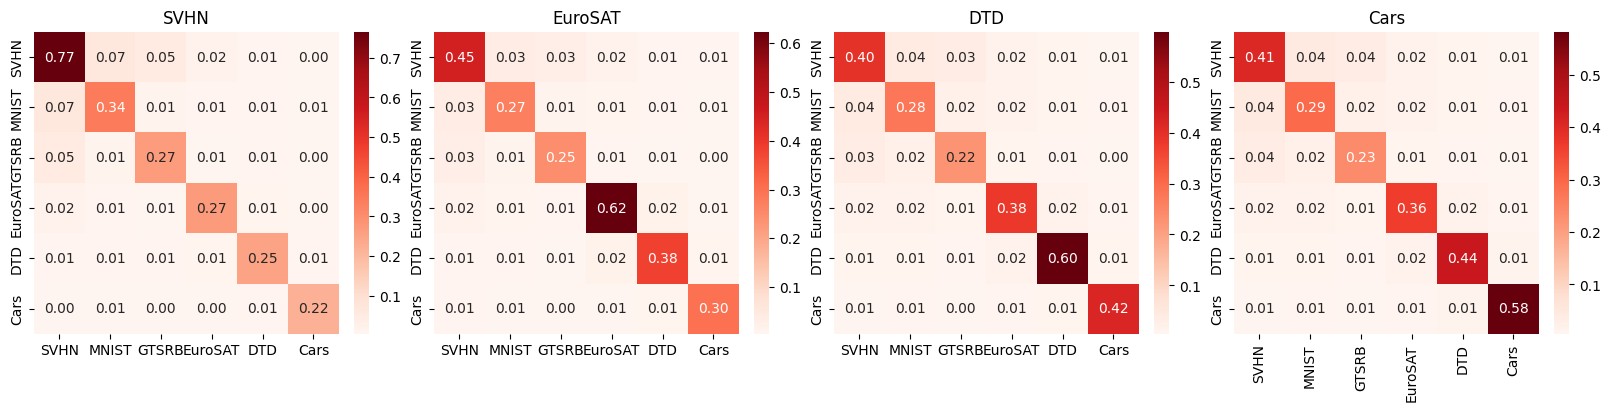

In [29]:
trace_shape = traces.shape
traces_mags = torch.linalg.norm(traces.reshape(N_TASKS_COV, N_LAYERS, -1), dim=-1)
traces_normed = traces / traces_mags.reshape(N_TASKS_COV, N_LAYERS, 1, 1)

import math
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(dataset_covs.keys())
T = len(labels)

ncols = min(4, T)
nrows = math.ceil(T / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= T:
        ax.remove()
        continue

    sns.heatmap(
        traces_normed.mean(dim=1)[i].numpy(),
        cmap="Reds",
        annot=True,
        fmt=".2f",
        xticklabels=task_list,
        yticklabels=task_list,
        ax=ax,
    )
    ax.set_title(labels[i])
    # ax.invert_yaxis()

plt.show()



Num. Rows: 4
Num. Cols: 4


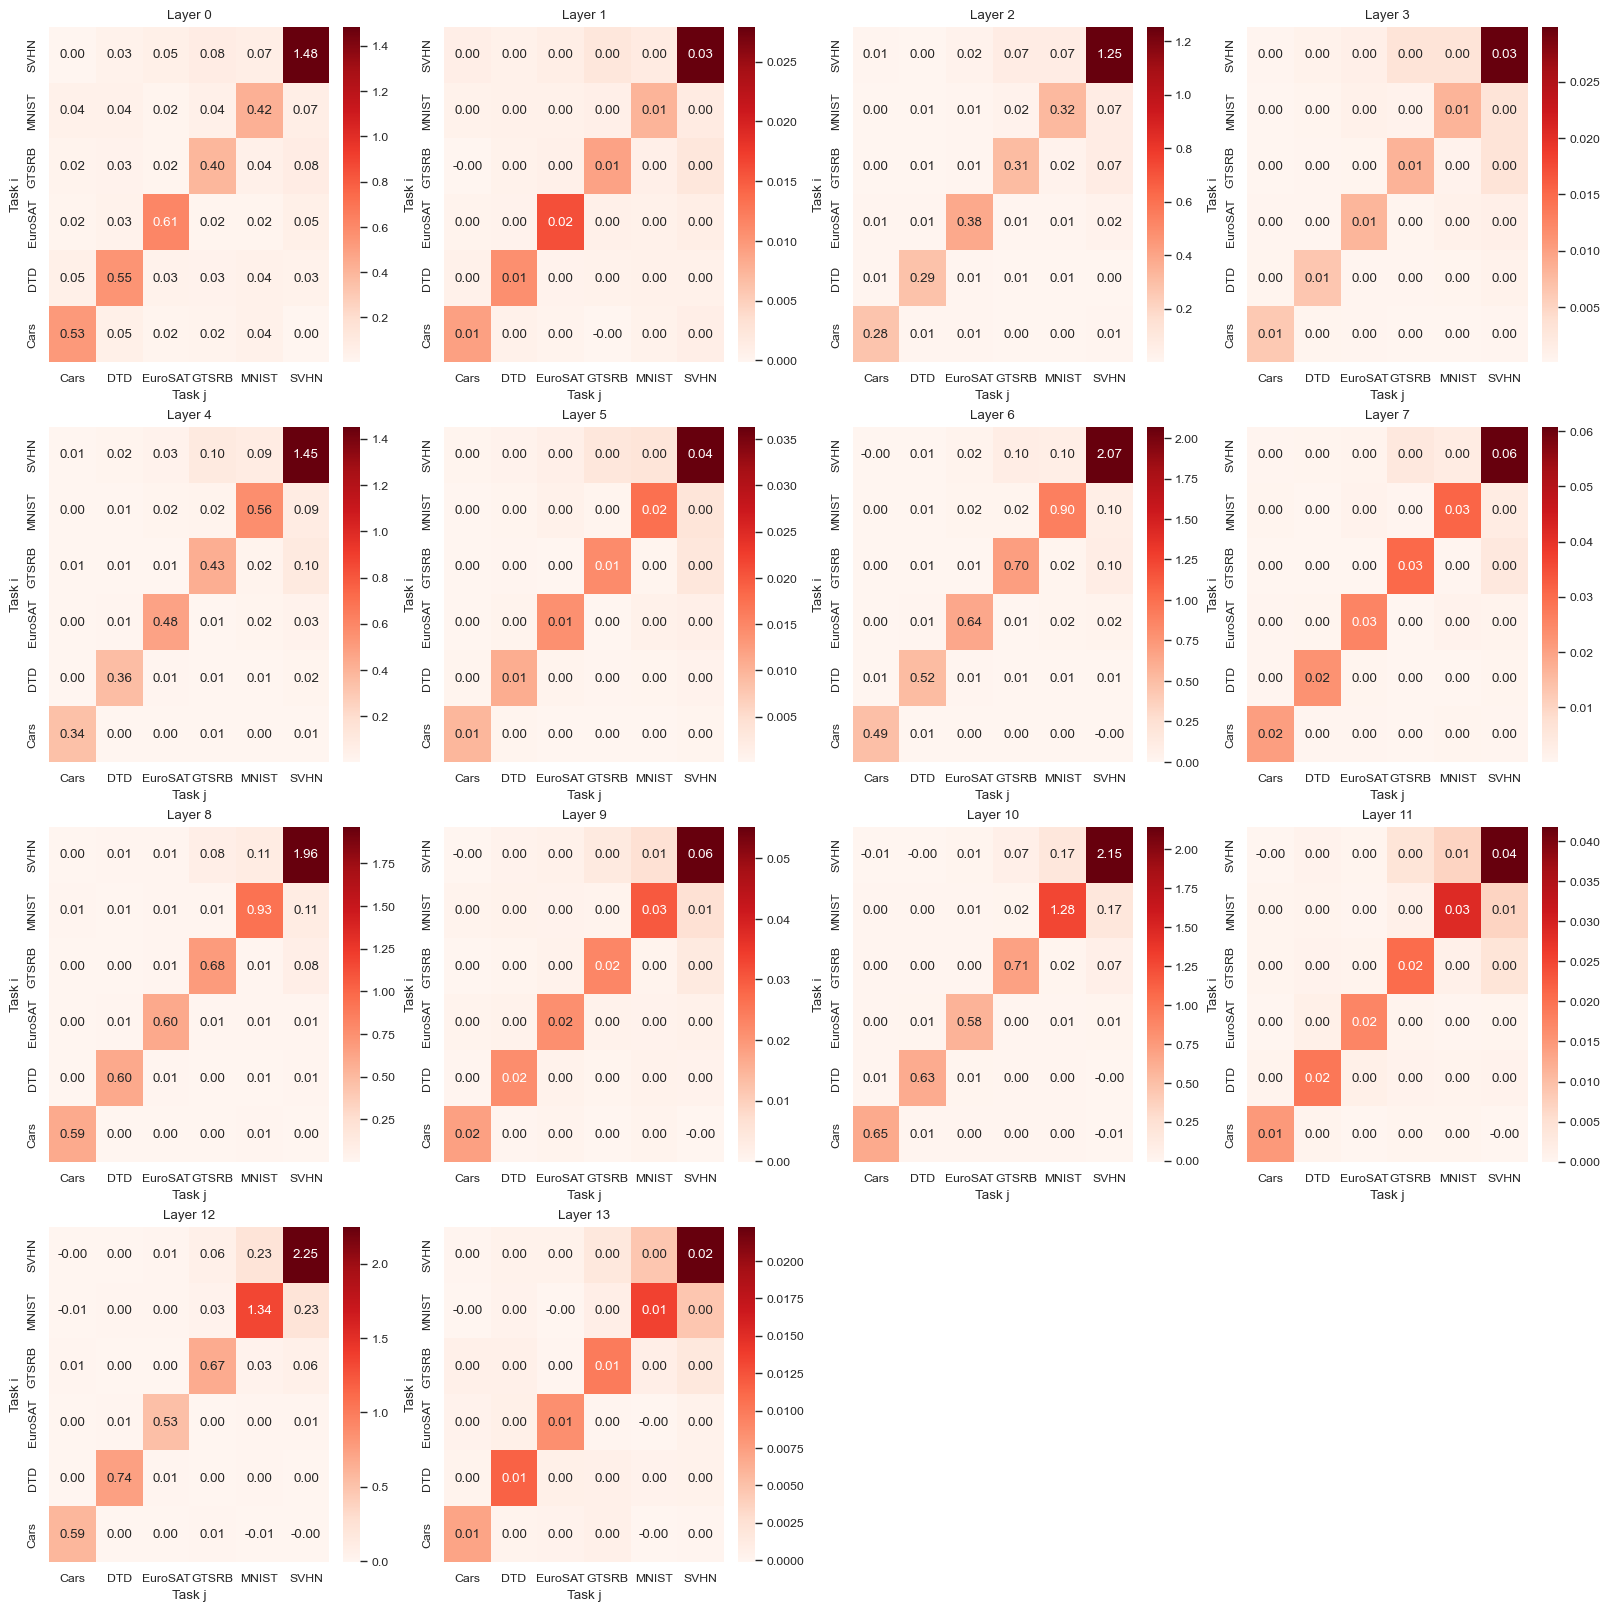

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

sns.set_theme()
sns.set_context("paper")
sns.set_palette("colorblind")

# Get public dataset (task) names from mats_dict['datasets'], assuming order matches
task_names = mats_dict.get('datasets', [str(i) for i in range(traces.shape[1])])

# Allow column wrap
max_cols = 4  # Max number of columns per row
n_cols = min(N_LAYERS, max_cols)
n_rows = math.ceil(N_LAYERS / n_cols)
print("Num. Rows:", n_rows)
print("Num. Cols:", n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

# Ensure axs is 2d array for easier indexing
axs = np.atleast_2d(axs)
axs = np.array(axs).reshape(n_rows, n_cols)

for l in range(N_LAYERS):
    row = l // n_cols
    col = l % n_cols
    ax = axs[row, col]
    sns.heatmap(
        traces[0, l].numpy(), 
        cmap="Reds", 
        ax=ax, 
        # square=True, 
        # cbar=(l == N_LAYERS - 1), 
        annot=True, 
        fmt=".2f",
        xticklabels=task_names,
        yticklabels=task_names
    )
    ax.set_title(f'Layer {l}')
    ax.set_xlabel('Task j')
    ax.set_ylabel('Task i')
    # invert y 
    ax.invert_yaxis()

# Hide unused subplots if any
for l in range(N_LAYERS, n_rows * n_cols):
    row = l // n_cols
    col = l % n_cols
    fig.delaxes(axs[row, col])

plt.show()

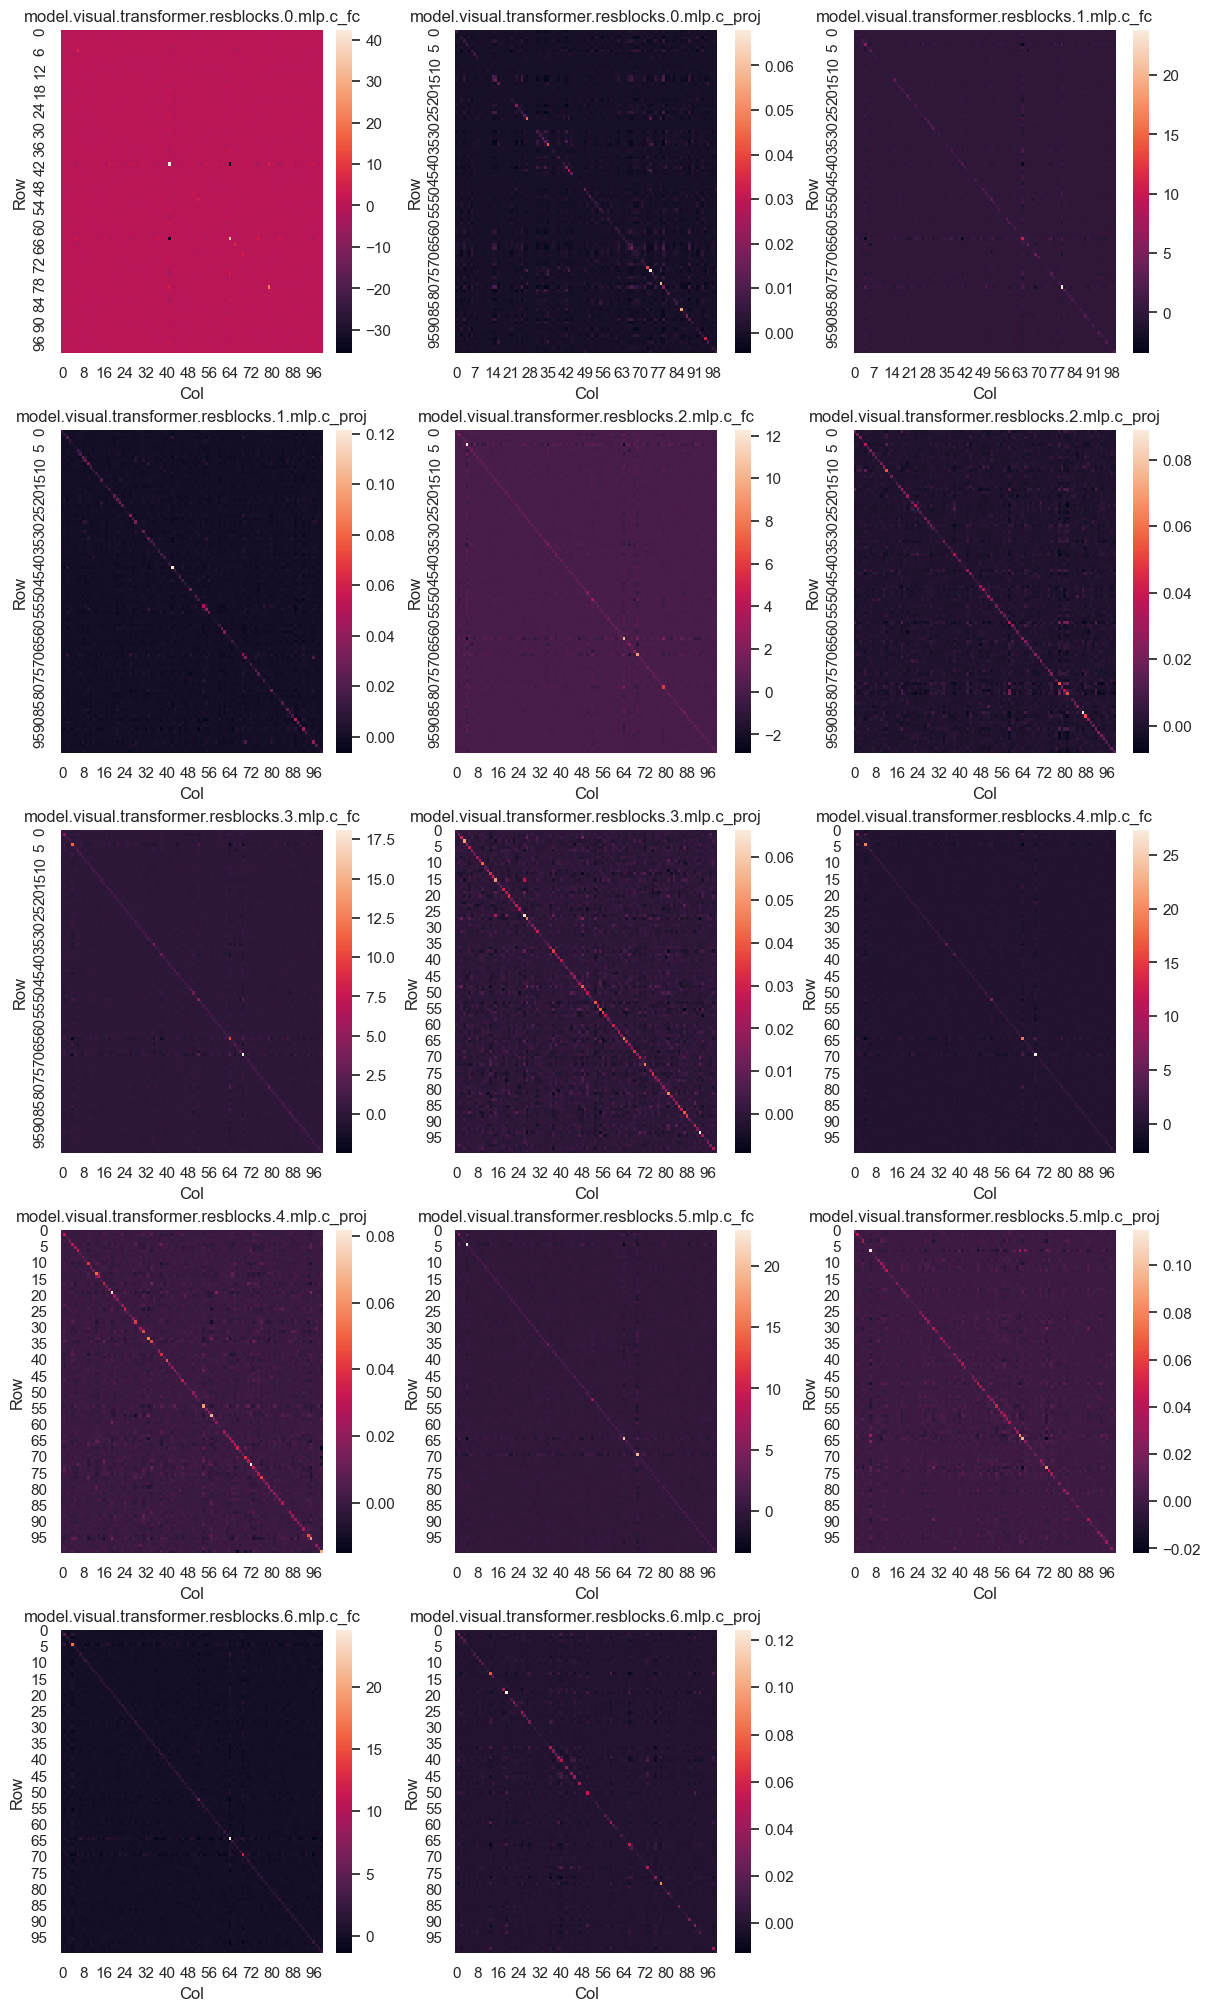

In [152]:
# Assume c is a 2D numpy array or torch tensor you want to plot as a heatmap
from matplotlib.colors import LogNorm
vmin, vmax = c.min(), c.max()

N_LAYERS = len(covs)
n_cols = min(N_LAYERS, 3)
n_rows = math.ceil(N_LAYERS / n_cols)
n_pts = 100 
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

axs = np.array(axs).reshape(-1)
for ax, layer_name in zip(axs, covs.keys()):
    c = torch.from_numpy(covs[layer_name]).float()[:n_pts, :n_pts]
    sns.heatmap(c, ax=ax)
    ax.set_title(layer_name)
    ax.set_xlabel("Col")
    ax.set_ylabel("Row")

for ax in axs[len(covs):]:
    ax.remove()
plt.show()



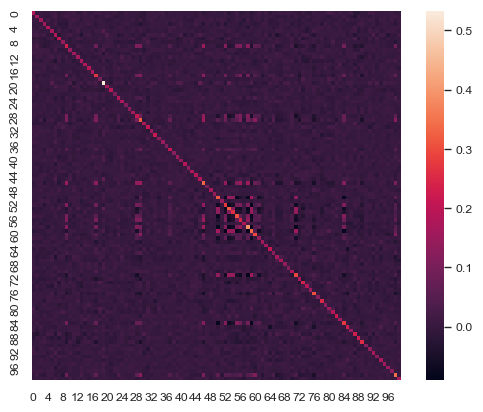

In [82]:
# Assume c is a 2D numpy array or torch tensor you want to plot as a heatmap
from matplotlib.colors import LogNorm
n_pts = 100 
cs = []
for layer_name in covs.keys():
    c = torch.from_numpy(covs[layer_name]).float()[:n_pts, :n_pts]
    cs.append(c)

c_avg = torch.stack(cs).mean(dim=0)
sns.heatmap(c_avg, cmap="rocket", square=True)
plt.show()


## MISC

MISC

In [ ]:

# *** Helpers OLD
def interference_old(a1, a2, n_points=10_000, batch_size=100):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I).

    Args:
        a1 (torch.Tensor): (Do, Di)
        a2 (torch.Tensor): (Do, Di)
        n_points (int, optional): Number of points to sample. Defaults to 10_000.
        batch_size (int, optional): Batch size for sampling. Defaults to 100.

    Returns:
        float: Interference.
    """
    total = 0.0
    device = a1.device
    Do, Di = a1.shape
    n_batches = n_points // batch_size
    for _ in range(n_batches):
        x = torch.randn(batch_size, Di, device=device)
        diff = a1 @ x.T - a2 @ x.T  # shape (Do, batch_size)
        norm = torch.linalg.norm(diff, dim=0)  # shape (batch_size,)
        total += norm.sum().item()
    return total / (n_batches * batch_size)

def merge_tsv(tensors, *args, **kwargs):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l



import matplotlib.pyplot as plt

v = torch.randn(2, 1)
v = v / torch.linalg.norm(v)
V = torch.cat([v, v], dim=1)  # (2, 2)
Vortho = compute_procrustes(V)
v_recons = 1/2 * Vortho.sum(dim=1, keepdim=True)  # (2, 1)

plt.figure(figsize=(6, 6))
plt.quiver([0, 0], [0, 0], V[0], V[1], angles='xy', scale_units='xy', scale=1, color=['b', 'b'], label='Original V')
plt.quiver([0, 0], [0, 0], Vortho[0], Vortho[1], angles='xy', scale_units='xy', scale=1, color=['r', 'r'], label='Ortho V')
plt.quiver([0], [0], v_recons[0], v_recons[1], angles='xy', scale_units='xy', scale=1, color=['g'], label='Reconstructed v')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.title('V before (blue), after (red) Procrustes, and v_recons (green)')
plt.legend(['Original V', 'Ortho V', 'Reconstructed v'])
plt.show()

# print lengths of v and v_recons
print(f"Length of v: {torch.linalg.norm(v).item():.4f}")
print(f"Length of v_recons: {torch.linalg.norm(v_recons).item():.4f}")


### TSV is close to Corrected WA

In [311]:
import torch
import math
import pandas as pd


D, Ta, Tb, Ka, Kb = 512, 2, 2, 8, 4
T = (Ka*Ta + Kb*Tb)
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


In [315]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

# TODO:
# [ ] Compare for different ground truth alpha and alpha sweeps for both WA and TSV

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv_sqmean = 1/math.sqrt(Ka*Ta) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb*Tb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = torch.einsum("ij,j,jk->ik", ua, sa, va.T) + torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) 
w_a_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/math.sqrt(Ka)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/math.sqrt(Kb)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)



# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "TA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.2f}"))



=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV  TA (Baseline)
Total Weight          2.01 4.88          10.85
Weight A              1.78 4.16           9.69
Weight B              1.38 2.37           3.58


### Least squares TSV

In [284]:
import torch

D, Ta, Tb, Ka, Kb = 512, 2, 2, 2, 1
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


2


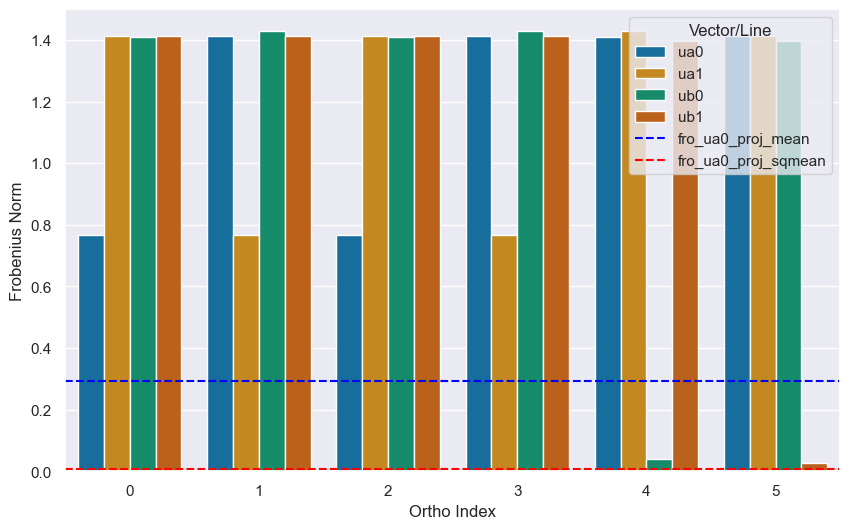

In [256]:
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()
# use colorblind palette
sns.set_palette("colorblind")

fros_ua0 = [torch.linalg.norm(U[:, 0] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ua1 = [torch.linalg.norm(U[:, 1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub0 = [torch.linalg.norm(U[:, -2] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub1 = [torch.linalg.norm(U[:, -1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]

ua0_proj = torch.stack([Uortho[:, i] for i in range(0, Uortho.shape[1]-Kb*Tb, 2)])
print(len(ua0_proj))
fro_ua0_proj_sqmean = torch.linalg.norm(U[:, 0] - (1/math.sqrt(Ka)) * ua0_proj.sum(dim=0)).item()
fro_ua0_proj_mean = torch.linalg.norm(U[:, 0] - (1/(Ka)) * ua0_proj.sum(dim=0)).item()

# Prepare data in longform for seaborn barplot
data = []
for idx in range(Uortho.shape[1]):
    data.append({'Ortho Index': idx, 'Vector': 'ua0', 'Frobenius Norm': fros_ua0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ua1', 'Frobenius Norm': fros_ua1[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub0', 'Frobenius Norm': fros_ub0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub1', 'Frobenius Norm': fros_ub1[idx]})
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Ortho Index", y="Frobenius Norm", hue="Vector")
plt.xlabel("Ortho Index")
plt.ylabel("Frobenius Norm")
plt.legend(title="Vector")

# Add the two Frobenius distances as lines
plt.axhline(fro_ua0_proj_mean, color="blue", linestyle="--", label="fro_ua0_proj_mean")
plt.axhline(fro_ua0_proj_sqmean, color="red", linestyle="--", label="fro_ua0_proj_sqmean")


# Avoid duplicate legend for hue + lines
handles, labels = plt.gca().get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Vector/Line")

plt.show()

In [257]:
# Check distance between ua @ sa @ vta and \sum_k uortho_k @ sortho_k @ vtortho_k

# w_a = ua @ sa @ vta
Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_a_tsv = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

cos_a_tsv = cos_sim(w_a_tsv, w_a_wagt)
cos_a_wa = cos_sim(w_a_wa, w_a_wagt)

diff_a_tsv = torch.linalg.norm(w_a_tsv - w_a_wagt)
diff_a_wa = torch.linalg.norm(w_a_wa - w_a_wagt)

# Now for b
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_b_tsv = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

cos_b_tsv = cos_sim(w_b_tsv, w_b_wagt)
cos_b_wa = cos_sim(w_b_wa, w_b_wagt)

diff_b_tsv = torch.linalg.norm(w_b_tsv - w_b_wagt)
diff_b_wa = torch.linalg.norm(w_b_wa - w_b_wagt)

# print(f"A: ‖tsv - wa‖ = {diff_a_tsv:.6f}, ‖wa - wagt‖ = {diff_a_wa:.6f}, intf_wa = {intf_a_wa:.6f}, intf_tsv = {intf_a_tsv:.6f}")
# print(f"B: ‖tsv - wa‖ = {diff_b_tsv:.6f}, ‖wa - wagt‖ = {diff_b_wa:.6f}, intf_wa = {intf_b_wa:.6f}, intf_tsv = {intf_b_tsv:.6f}")


# Create merges
# w_tsv = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = 1/(Ka*Kb) * torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)

# Nicer, informative printout of interference results
intf_tsv_wagt = interference(w_tsv, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)
print(f"Interference between w_tsv and w_wagt: {intf_tsv_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# intf_b_tsv = interference(w_b_tsv, w_wagt)
# intf_b_wa = interference(w_b_wa, w_wagt)

# intf_a_tsv = interference(w_a_tsv, w_wagt)
# intf_a_wa = interference(w_a_wa, w_wagt)


RuntimeError: einsum(): subscript j has size 2 for operand 2 which does not broadcast with previously seen size 4

In [289]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T) * 1/Uortho.shape[1]
w_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T) * 1/U.shape[1]
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)


import pandas as pd

# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV (Mean)":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "WA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.6f}"))


# print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
# print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# print(f"Interference between w_a_tsv_sqmean and w_a_wagt: {intf_a_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_a_tsv_mean and w_a_wagt : {intf_a_tsv_mean_wagt:.6f}")
# print(f"Interference between w_a_wa and w_a_wagt : {intf_a_wa_wagt:.6f}")

# print(f"Interference between w_b_tsv_sqmean and w_b_wagt: {intf_b_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_b_tsv_mean and w_b_wagt : {intf_b_tsv_mean_wagt:.6f}")
# print(f"Interference between w_b_wa and w_b_wagt : {intf_b_wa_wagt:.6f}")


=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV (Mean)  WA (Baseline)
Total Weight      0.723188    0.427816       0.347982
Weight A          0.473931    0.239249       0.312626
Weight B          0.480723    0.027959       0.000000


In [282]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_wa_wagt = interference(w_a_wa, w_a_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 0.767726
Interference between w_tsv_mean and w_wagt : 0.385526
Interference between w_wa and w_wagt : 0.500862


In [283]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_wa_wagt = interference(w_b_wa, w_b_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 1.174928
Interference between w_tsv_mean and w_wagt : 0.591940
Interference between w_wa and w_wagt : 0.759910


In [49]:
import torch
from tqdm import tqdm

batched_kron = torch.vmap(torch.kron)
def make_ls_mats(pus, pvs, a_tilde):
    """Create least squares params from task proj mats and target mat

    Args:
        pus (torch.Tensor): Task left proj mats. Shape: (B, Do, Do)
        pvs (torch.Tensor): Task right proj mats. Shape: (B, Di, Di)
        a_tilde (torch.Tensor): Target mat. Shape: (B, Do, Di)

    Returns:
        mis_stack (torch.Tensor): (B*D, D)
        a_tilde_flat (torch.Tensor): (B*D*D)
    """
    B, Do, Di = a_tilde.shape
    D = Do*Di
    mis = batched_kron(pvs, pus)
    a_tilde_flat = a_tilde.reshape(-1)  # (B*Do*Di)
    mis_stack = mis.reshape(-1, D)  # (B*D, D)
    return mis_stack, a_tilde_flat


def merge_avg(a_tilde):
    return a_tilde.mean(dim=0)


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat):
    pred = mis_stack @ a_hat.reshape(-1)
    loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
    return loss


def compute_lsopt_loss_gd(a_hat, a_tilde):
    """Computes the loss for the LSopt optimization.

    Args:
        a_hat (torch.Tensor): (Do, Di)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = max(1, R // B)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]
    pus = u @ u.transpose(1, 2)  # (B, Do, Do)
    v = vt.transpose(1, 2)
    pvs = v @ vt  # (B, Di, Di)
    preds = torch.einsum("boj,jk,bki->boi", pus, a_hat, pvs)
    loss = torch.linalg.norm(preds - a_tilde, ord="fro", dim=(1, 2)).square().mean()
    return loss



def merge_lsopt_gd(a_tilde, verbose=False, max_iter=1000, tol=1e-8, lr=0.01):
    B, Do, Di = a_tilde.shape
    device = a_tilde.device

    # mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    a_hat = torch.nn.Parameter(torch.randn(Do, Di, device=device, dtype=a_tilde.dtype))
    opt = torch.optim.AdamW([a_hat], lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, "min", patience=10, factor=0.1
    )

    loss_prev = float("inf")
    for it in tqdm(range(max_iter), desc="LSopt GD", leave=False):
        opt.zero_grad()
        # pred = mis_stack @ a_hat.reshape(-1)
        # loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
        # loss = compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat)
        loss = compute_lsopt_loss_gd(a_hat, a_tilde)

        loss.backward()
        opt.step()
        sched.step(loss.item())

        lv = loss.item()
        if verbose:
            print(f"iter {it}, loss {lv}")

        if abs(lv - loss_prev) < tol:
            if verbose:
                print(f"Converged in {it} iterations")
            break
        loss_prev = lv

    return a_hat.detach()



def merge_lsopt(a_tilde, verbose=False):
    """
    Args:
        a_tilde (torch.Tensor): Task matrices. Shape: (B, Do, Di)
        verbose (bool): Whether to print debug info

    Returns:
        a_hat (torch.Tensor): Merged task matrix. Shape: (Do, Di)
    """
    # B, Do, Di = 8, 32, 64
    # a_tilde = torch.randn(B, Do, Di)
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    # truncate
    R = min(u.shape[1], vt.shape[2])
    Rp = R // len(a_tilde)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]

    ut = u.permute(0, 2, 1)
    v = vt.permute(0, 2, 1)
    pus = torch.einsum('bij,bjk->bik', u, ut)
    pvs = torch.einsum('bij,bjk->bik', v, vt)

    mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    if verbose:
        print('pus.shape', pus.shape)
        print('pvs.shape', pvs.shape)
        print('batched_kron.shape', batched_kron(pus, pvs).shape)
        print('mis_stack.shape', mis_stack.shape)
        print('a_tilde_flat.shape', a_tilde_flat.shape)

    print("Computing LS solution...")
    sol = torch.linalg.lstsq(mis_stack, a_tilde_flat)
    print("Done.")
    a_hat_vec = sol.solution
    a_hat = a_hat_vec.reshape(Do, Di)
    return a_hat

def compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde):
    """Computes the loss for the TSV optimization.

    Args:
        u_ortho (torch.Tensor): (Di, Rp)
        vt_ortho (torch.Tensor): (Rp, Do)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    pred = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    loss = (
        torch.linalg.norm(pred.unsqueeze(0) - a_tilde, ord="fro", dim=(1, 2))
        .square()
        .mean()
    )  # (B, Do, Di)
    return loss

def merge_tsvopt(a_tilde, verbose=False, n_iters=100, *args, **kwargs):
    N_tasks = len(a_tilde)
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    # s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)

    # Get optimal singular values
    s_hat = torch.nn.Parameter(s.reshape(-1).clone())
    opt = torch.optim.AdamW([s_hat], lr=0.01)
    for t in range(n_iters):
        opt.zero_grad()
        loss = compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde)
        loss.backward()
        opt.step()
    return torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)

B, Do, Di = 8, 32, 64
a_tilde = torch.randn(B, Do, Di)
# a_hat_1 = merge_lsopt(a_tilde)
a_hat_2 = merge_lsopt_gd(a_tilde, max_iter=1000, tol=1e-8, verbose=False)
# a_hat_3 = merge_tsvopt(a_tilde, n_iters=100)
print(a_hat_2.shape)
# print("Allclose?", torch.allclose(a_hat_1, a_hat_2, atol=1e-4))
# >>> torch.allclose(a_hat_1, a_hat_2, atol=1e-5)
# False

torch.Size([32, 64])


In [44]:
# B, Do, Di = 8, 32, 64
# a_tilde = torch.randn(B, Do, Di)
B, Do, Di = a_tilde.shape
u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
# truncate
R = min(u.shape[1], vt.shape[2])
Rp = R // len(a_tilde)
u = u[:, :, :Rp]
vt = vt[:, :Rp, :]

ut = u.permute(0, 2, 1)
v = vt.permute(0, 2, 1)
pus = torch.einsum('bij,bjk->bik', u, ut)
pvs = torch.einsum('bij,bjk->bik', v, vt)

mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)

loss_rand = compute_lsopt_loss(torch.randn(Do, Di), mis_stack, a_tilde_flat)
loss_lsopt = compute_lsopt_loss(a_hat_1, mis_stack, a_tilde_flat)
loss_lsopt_gd = compute_lsopt_loss(a_hat_2, mis_stack, a_tilde_flat)

print("Loss rand", loss_rand.item())
print("Loss lsopt", loss_lsopt.item())
print("Loss lsopt_gd", loss_lsopt_gd.item())


Loss rand 1.0221692323684692
Loss lsopt 1.0026545524597168
Loss lsopt_gd 1.0294201374053955


Computing LS solution...
Done.


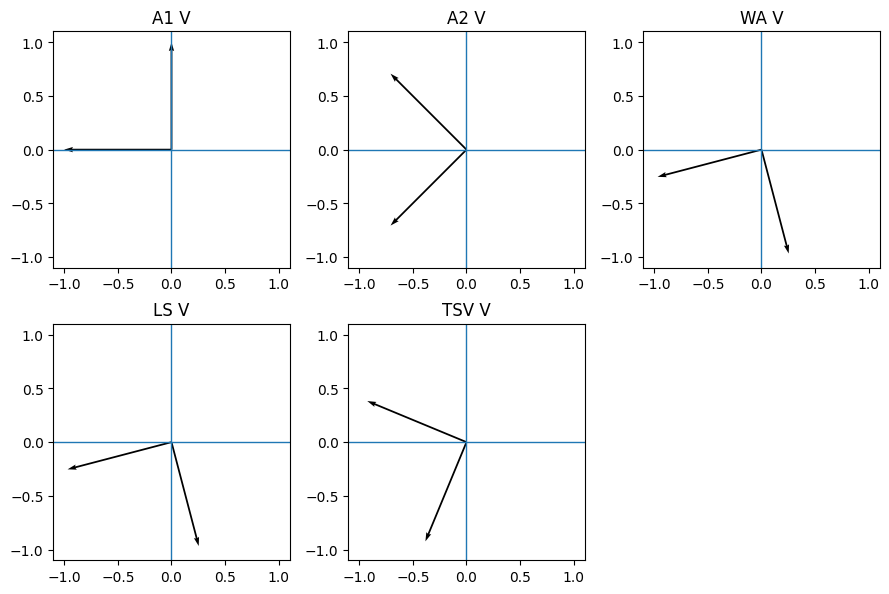

In [ ]:
import matplotlib.pyplot as plt
import math
# ----------------------------
# Toy with tunable orthogonality
# ----------------------------
ortho = 0.5                 # 0 = aligned, 1 = orthogonal
theta_v = ortho * (math.pi/2)

B, Do, Di = 2, 2, 2

v1 = torch.tensor([1.0, 0.0])
v2 = torch.tensor([math.cos(theta_v), math.sin(theta_v)])

u1 = torch.tensor([1.0, 1.0]);  u1 = u1 / u1.norm()
u2 = torch.tensor([1.0, -1.0]); u2 = u2 / u2.norm()

s1, s2 = 2.0, 1.5
A1 = s1 * torch.outer(u1, v1)
A2 = s2 * torch.outer(u2, v2)
a_tilde = torch.stack([A1, A2], dim=0)

A_wa  = merge_avg(a_tilde)
A_ls  = merge_lsopt(a_tilde)
A_tsv = merge_tsv(a_tilde)


# ----------------------------
# Plot right singular vectors
# ----------------------------
def right_singular_vecs(A):
    _, _, Vt = torch.linalg.svd(A, full_matrices=False)
    return Vt.T

def plot_right_vecs(ax, A, title):
    V = right_singular_vecs(A)
    ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
    ax.quiver([0,0], [0,0], V[0,:], V[1,:],
              angles='xy', scale_units='xy', scale=1)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
plot_right_vecs(axs[0,0], A1,  "A1 V")
plot_right_vecs(axs[0,1], A2,  "A2 V")
plot_right_vecs(axs[0,2], A_wa,"WA V")
plot_right_vecs(axs[1,0], A_ls,"LS V")
plot_right_vecs(axs[1,1], A_tsv,"TSV V")
axs[1,2].axis("off")
plt.tight_layout()
plt.show()

### Geometric interpretation of TSV

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_56485/1681312568.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = A @ X_unit_sphere


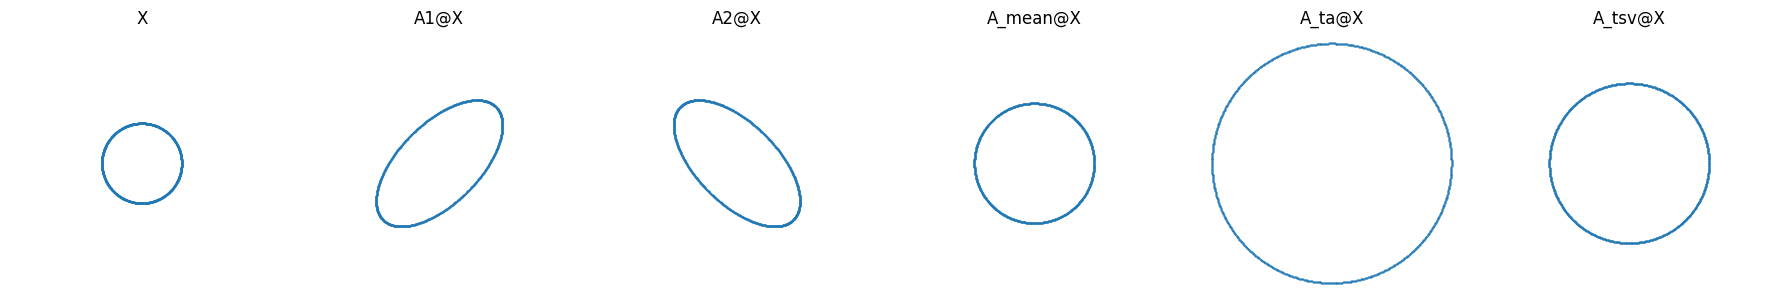

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def rot(deg):
    t = np.deg2rad(deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s], [s, c]])

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As, r=1):
    # U = np.concatenate([np.linalg.svd(A, full_matrices=False)[0][:, :r] for A in As], axis=1)
    # V = np.concatenate([np.linalg.svd(A, full_matrices=False)[2].T[:, :r] for A in As], axis=1)
    # U, _ = np.linalg.qr(U)
    # V, _ = np.linalg.qr(V)
    # Abar = merge_mean(As)
    # B = U.T @ Abar @ V
    # Ub, s, Vhb = np.linalg.svd(B, full_matrices=False)
    # return U @ (Ub * s) @ Vhb @ V.T
    return get_tsv_merge(torch.stack([torch.from_numpy(A) for A in As]))


# data on unit circle
tvs = np.linspace(0, 2*np.pi, 800, endpoint=False)
X_unit_sphere = np.stack([np.cos(tvs), np.sin(tvs)])

R1, R2 = rot(45), rot(-45)
S = np.diag([2.0, 1.0])
A1 = R1 @ S @ R1.T
A2 = R2 @ S @ R2.T

A_mean = merge_mean([A1, A2])
A_ta = merge_ta([A1, A2])
A_tsv  = merge_tsv([A1, A2], r=1)

mats = [
    ("X", np.eye(2)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A_mean@X", A_mean),
    ("A_ta@X", A_ta),
    ("A_tsv@X", A_tsv),
]

fig, ax = plt.subplots(1, len(mats), figsize=(3*len(mats), 3), sharex=True, sharey=True)
for a, (title, A) in zip(ax, mats):
    Y = A @ X_unit_sphere
    a.plot(Y[0], Y[1], ".", ms=1)
    a.set_title(title); a.set_aspect("equal"); a.axis("off")
plt.tight_layout(); plt.show()


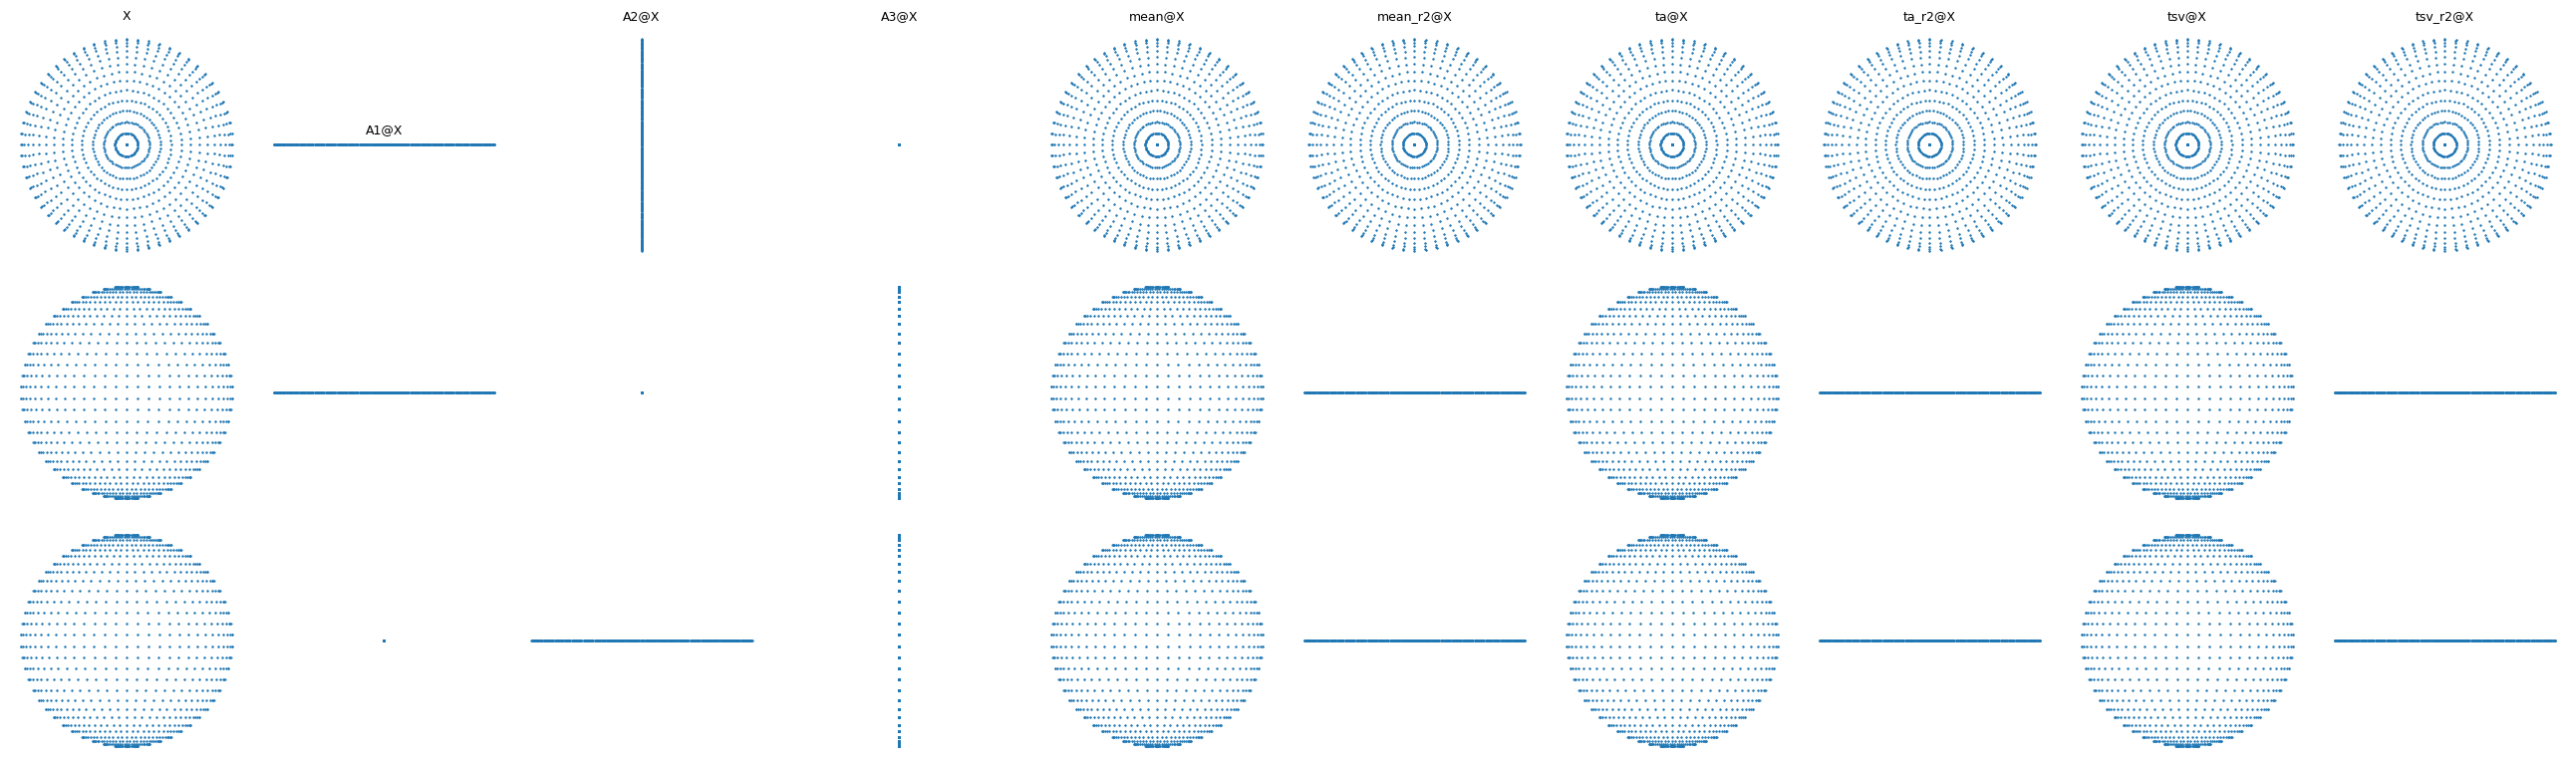

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def best_rank_k_np(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks  # rank per task (with full SVD this becomes 1 in 3-task, 3D case)
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    B, Di, _ = u.shape
    _, _, Do = vt.shape
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)

    u_ortho = compute_procrustes(u_hat)
    vt_ortho = compute_procrustes(vt_hat.T).T
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As):
    return get_tsv_merge(torch.stack([torch.from_numpy(A).float() for A in As])).numpy()


# =========================
# 🔥 MINIMAL “AHA” CHANGES:
# 1) go to 3D
# 2) use 3 rank-1 “tasks” on different axes
# 3) enforce a rank budget after merging (rank-2)
# 4) visualize via 2D projections (xy, xz, yz)
# =========================

# data on unit sphere in 3D
phi = np.linspace(0, 2*np.pi, 60, endpoint=False)
theta_v = np.linspace(0, np.pi, 30, endpoint=True)
phi, theta_v = np.meshgrid(phi, theta_v)
X_unit_sphere = np.stack([
    np.sin(theta_v) * np.cos(phi),
    np.sin(theta_v) * np.sin(phi),
    np.cos(theta_v),
]).reshape(3, -1)

# three rank-1-ish maps, orthogonal directions
A1 = np.diag([2.0, 0.0, 0.0])  # stretch x
A2 = np.diag([0.0, 2.0, 0.0])  # stretch y
A3 = np.diag([0.0, 0.0, 2.0])  # stretch z
As = [A1, A2, A3]

A_mean = merge_mean(As)
A_ta   = merge_ta(As)
A_tsv  = merge_tsv(As)

# enforce the same rank budget (this is where WA vs TSV diverge)
k = 2
A_mean_k = best_rank_k_np(A_mean, k)
A_ta_k   = best_rank_k_np(A_ta, k)
A_tsv_k  = best_rank_k_np(A_tsv, k)

mats = [
    ("X", np.eye(3)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A3@X", A3),

    ("mean@X", A_mean),
    (f"mean_r{k}@X", A_mean_k),

    ("ta@X", A_ta),
    (f"ta_r{k}@X", A_ta_k),

    ("tsv@X", A_tsv),
    (f"tsv_r{k}@X", A_tsv_k),
]

# plot 2D projections: xy, xz, yz
projs = [("xy", (0, 1)), ("xz", (0, 2)), ("yz", (1, 2))]

fig, ax = plt.subplots(
    len(projs), len(mats),
    figsize=(2.6 * len(mats), 2.6 * len(projs)),
    sharex=False, sharey=False
)

for r, (pname, (i, j)) in enumerate(projs):
    for c, (title, A) in enumerate(mats):
        Y = A @ X_unit_sphere
        ax[r, c].plot(Y[i], Y[j], ".", ms=1)
        if r == 0:
            ax[r, c].set_title(title, fontsize=9)
        if c == 0:
            ax[r, c].set_ylabel(pname, rotation=0, labelpad=12, fontsize=10)
        ax[r, c].set_aspect("equal")
        ax[r, c].axis("off")

plt.tight_layout()
plt.show()


### OPT

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )

# # Pull out single matrix
# mats = []

# for key in task_vectors[0].vector:
#     if len(task_vectors[0].vector[key].shape) == 2 and "text_projection" not in key:
#         if task_vectors[0].vector[key].min() == task_vectors[0].vector[key].max() == 0:
#             continue
#         for tv in task_vectors:
#             mats.append(tv.vector[key])
#         break

# mats = torch.stack(mats)

In [ ]:
# Pull out single matrix
mats = []

for layer_name in task_vectors[0].vector:
    if len(task_vectors[0].vector[layer_name].shape) == 2 and "text_projection" not in layer_name:
        if task_vectors[0].vector[layer_name].min() == task_vectors[0].vector[layer_name].max() == 0:
            continue
        for tv in task_vectors:
            mats.append(tv.vector[layer_name])
        break

mats = torch.stack(mats)

In [ ]:
# Save the mats
torch.save(mats, "results/mats.pt")

In [16]:
import torch
# Load the mats
mats = torch.load("results/mats.pt")
print(mats.shape), mats.min(), mats.max()


torch.Size([6, 197, 768])


(None, tensor(-0.0014), tensor(0.0015))

In [32]:
import numpy as np
def calc_rank(S, norm_thresh=0.95):
    # Rank based on approximation error (Eq. 6) in the paper
    rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)
    return rank

def compute_sar(u, s, mats):

    # figure out effective rank
    rank_eff = calc_rank(s)
    u = u[:, :rank_eff]

    proj_m_w = torch.einsum("ij,jk,bkl->bil", u, u.T, mats)
    return torch.linalg.norm(proj_m_w, ord="fro", dim=(1, 2)) / torch.linalg.norm(mats, ord="fro", dim=(1, 2))  # (b,)


def compute_delta_m_sum(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    return delta_m, u, s

def compute_delta_m_iso(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    s_mean = torch.ones_like(s) * s.mean()
    return torch.einsum("ij,j,jk->ik", u, s_mean, vt), u, s

def compute_delta_m_opt(mats):
    delta_t_outers = torch.einsum("bik,bkj->bij", mats, mats.permute(0, 2, 1))
    delta_t_frobs = torch.linalg.norm(mats, ord="fro", dim=(1, 2))[
        :, None, None
    ]
    mat_a = (delta_t_outers / delta_t_frobs).sum(dim=0)
    lam, u = torch.linalg.eig(mat_a)
    return None, u, torch.ones_like(lam)

methods = [
    ("sum", compute_delta_m_sum),
    ("iso", compute_delta_m_iso),
    ("opt", compute_delta_m_opt),
]

rows = []
for method_name, method_fn in methods:
    delta_m, u, s = method_fn(mats)
    sar_m = compute_sar(u, s, mats)
    rows.append({"method": method_name, "sar": sar_m})

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_36156/1199381627.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)


NotImplementedError: "gt_cpu" not implemented for 'ComplexFloat'

In [28]:
rows

[{'method': 'sum',
  'sar': tensor([0.7909, 0.8007, 0.8295, 0.8179, 0.8240, 0.8547])},
 {'method': 'iso',
  'sar': tensor([0.9549, 0.9521, 0.9563, 0.9526, 0.9525, 0.9568])}]